# IMPROVE HIPS Offset Narrative

This notebook is the IMPROVE counterpart to `research/ftir_hips_chem/hips_offset_narrative.ipynb`.

The earlier `improve_high_fabs_comparison.ipynb` answered a broad data-availability question. This notebook asks the narrower instrument-regime question:

> Among IMPROVE samples that are actually comparable to ETAD/Addis by filter loading, do the HIPS/fAbs diagnostics resemble the Addis HIPS offset regime?

The key difference is that this notebook does not use all high-`fAbs` IMPROVE points as the main comparison. It first rebuilds the ETAD reference regime from local SPARTAN data, then filters IMPROVE to samples with valid raw RT fields and ETAD-like EC surface loading.


In [1]:
\
from pathlib import Path
import os
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from IPython.display import display

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 120)
pd.set_option('display.max_colwidth', 140)
pd.set_option('display.width', 160)

PROJECT_DIR = Path('/Users/ahmadjalil/github/aethmodular')
SPARTAN_DIR = PROJECT_DIR / 'research' / 'ftir_hips_chem'
THIS_DIR = PROJECT_DIR / 'research' / 'improve_hips_offset'
OUT_DIR = THIS_DIR / 'output' / 'improve_hips_offset_narrative'
OUT_DIR.mkdir(parents=True, exist_ok=True)

IMPROVE_DIR = Path('/Users/ahmadjalil/Library/CloudStorage/GoogleDrive-ahzs645@gmail.com/My Drive/University/Research/Grad/UC Davis Ann/NASA MAIA/Data/Improve')
SPARTAN_FILTER_PATH = SPARTAN_DIR / 'Filter Data' / 'unified_filter_dataset.pkl'
DEFAULT_DRIVE_ROOT = (
    Path.home()
    / 'Library/CloudStorage/GoogleDrive-ahzs645@gmail.com/My Drive/University/Research/Grad/UC Davis Ann/NASA MAIA/Data'
)
DRIVE_ROOT = Path(os.environ.get('AETHMODULAR_MAIA_DATA_ROOT', DEFAULT_DRIVE_ROOT)).expanduser().resolve()
RAW_HIPS_PATH = DRIVE_ROOT / 'Combine csv files' / 'Raw Datafiles' / 'Four_Sites_HIPS_data.csv'
SCRIPTS_DIR = SPARTAN_DIR / 'scripts'
if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

try:
    from outliers import apply_exclusion_flags, apply_threshold_flags
except Exception as exc:
    apply_exclusion_flags = None
    apply_threshold_flags = None
    print(f'Warning: could not import SPARTAN exclusion helpers: {exc}')

SITE_CODE_TO_NAME = {
    'CHTS': 'Beijing',
    'INDH': 'Delhi',
    'USPA': 'JPL',
    'ETAD': 'Addis_Ababa',
}
SITE_ORDER = ['Beijing', 'Delhi', 'JPL', 'Addis_Ababa']
SITE_COLORS = {
    'Beijing': '#c44e52',
    'Delhi': '#4c72b0',
    'JPL': '#55a868',
    'Addis_Ababa': '#dd8452',
}

MAC_VALUE = 10.0
PRIMARY_IMPROVE_AREA_CM2 = 3.5
HIGH_TAIL_THRESHOLD = 70.0
MIN_EC = 0.5
NA_VALUES = [-999, '-999', -999.0, '-999.0']

print(f'Project: {PROJECT_DIR}')
print(f'Output: {OUT_DIR}')
print(f'IMPROVE files: {IMPROVE_DIR}')


Project: /Users/ahmadjalil/github/aethmodular
Output: /Users/ahmadjalil/github/aethmodular/research/improve_hips_offset/output/improve_hips_offset_narrative
IMPROVE files: /Users/ahmadjalil/Library/CloudStorage/GoogleDrive-ahzs645@gmail.com/My Drive/University/Research/Grad/UC Davis Ann/NASA MAIA/Data/Improve


## 1. Rebuild the ETAD/SPARTAN reference regime

The comparison should be anchored to the local Addis/ETAD filters, not to arbitrary IMPROVE thresholds. This section rebuilds the same SPARTAN reference pieces used in the Addis HIPS narrative:

- filtered HIPS vs FTIR EC relationship
- ETAD `HIPS_Fabs` range
- ETAD EC mass and surface loading ranges
- ETAD raw HIPS transmittance regime relative to blanks


In [2]:
\
def regression_stats(df, x_col, y_col):
    pair = df[[x_col, y_col]].replace([np.inf, -np.inf], np.nan).dropna().copy()
    pair = pair[(pair[x_col] > 0) & (pair[y_col] > 0)]
    if len(pair) < 3 or pair[x_col].nunique() < 2:
        return {'n': len(pair), 'slope': np.nan, 'intercept': np.nan, 'r2': np.nan, 'origin_mac': np.nan}
    x = pair[x_col].to_numpy(float)
    y = pair[y_col].to_numpy(float)
    slope, intercept, r, p, se = stats.linregress(x, y)
    origin_mac = np.dot(x, y) / np.dot(x, x)
    return {'n': len(pair), 'slope': slope, 'intercept': intercept, 'r2': r**2, 'origin_mac': origin_mac}


def display_fit_table(groups, x_col='ECf_Val', y_col='fAbs_Val'):
    rows = []
    for name, g in groups.items():
        row = {'group': name}
        row.update(regression_stats(g, x_col, y_col))
        row['site_count'] = g['SiteCode'].nunique() if 'SiteCode' in g else np.nan
        row['fAbs_median'] = g[y_col].median() if y_col in g else np.nan
        row['EC_median'] = g[x_col].median() if x_col in g else np.nan
        rows.append(row)
    return pd.DataFrame(rows)


df_long = pd.read_pickle(SPARTAN_FILTER_PATH)
df_long['SampleDate'] = pd.to_datetime(df_long['SampleDate'], errors='coerce')
df_long['SiteName'] = df_long['Site'].map(SITE_CODE_TO_NAME)

if RAW_HIPS_PATH.exists():
    spartan_hips_raw = pd.read_csv(RAW_HIPS_PATH)
    spartan_hips_raw['SampleDate'] = pd.to_datetime(spartan_hips_raw['SampleDate'], errors='coerce')
    spartan_hips_raw['SiteName'] = spartan_hips_raw['Site'].map(SITE_CODE_TO_NAME)
    RAW_HIPS_AVAILABLE = True
else:
    spartan_hips_raw = pd.DataFrame()
    RAW_HIPS_AVAILABLE = False
    print(f'Warning: raw HIPS export not found: {RAW_HIPS_PATH}')

pivot_params = [
    'EC_ftir', 'HIPS_Fabs', 'HIPS_tau', 'HIPS_T1', 'HIPS_R1', 'HIPS_t', 'HIPS_r',
    'HIPS_Intercept', 'HIPS_Slope', 'ChemSpec_OC_PM2.5', 'ChemSpec_Filter_PM2.5_mass',
]
filter_wide = (
    df_long[df_long['Parameter'].isin(pivot_params)]
    .pivot_table(
        index=['Site', 'SiteName', 'FilterId', 'SampleDate', 'FilterType', 'LotId', 'DepositArea_cm2', 'Volume_m3'],
        columns='Parameter',
        values='Concentration',
        aggfunc='first',
    )
    .reset_index()
)
filter_wide.columns.name = None

# Attach EC mass loading from the long EC row, because pivoting concentrations drops MassLoading_ug.
ec_mass = (
    df_long[df_long['Parameter'].eq('EC_ftir')][['FilterId', 'MassLoading_ug']]
    .drop_duplicates('FilterId')
    .rename(columns={'MassLoading_ug': 'EC_loading_ug'})
)
filter_wide = filter_wide.merge(ec_mass, on='FilterId', how='left')
filter_wide['HIPS_BC'] = filter_wide['HIPS_Fabs'] / MAC_VALUE
filter_wide['EC_loading_ug_cm2'] = filter_wide['EC_loading_ug'] / filter_wide['DepositArea_cm2']
filter_wide['t_plus_r'] = filter_wide.get('HIPS_t', np.nan) + filter_wide.get('HIPS_r', np.nan)

clean_frames = []
for site_name in SITE_ORDER:
    site_code = [code for code, label in SITE_CODE_TO_NAME.items() if label == site_name][0]
    site_df = filter_wide[(filter_wide['Site'] == site_code) & (filter_wide['FilterType'] == 'PM2.5')].copy()
    site_df['aeth_bc'] = pd.NA
    site_df['filter_ec'] = site_df['EC_ftir'] * 1000.0
    site_df['date'] = site_df['SampleDate']
    site_df['filter_id'] = site_df['FilterId']
    if apply_exclusion_flags is not None and apply_threshold_flags is not None:
        site_df = apply_exclusion_flags(site_df, site_name)
        site_df = apply_threshold_flags(site_df, site_name)
        mask = (~site_df['is_excluded']) & (~site_df['is_outlier'])
    else:
        mask = pd.Series(True, index=site_df.index)
    clean_df = site_df[
        mask
        & site_df['EC_ftir'].notna()
        & site_df['HIPS_BC'].notna()
        & (site_df['EC_ftir'] >= MIN_EC)
    ].copy()
    clean_frames.append(clean_df)
clean_pm25 = pd.concat(clean_frames, ignore_index=True)

spartan_fit = (
    clean_pm25.groupby('SiteName')
    .apply(lambda g: pd.Series(regression_stats(g, 'EC_ftir', 'HIPS_BC')))
    .reindex(SITE_ORDER)
)

etad = clean_pm25[clean_pm25['SiteName'].eq('Addis_Ababa')].copy()
if RAW_HIPS_AVAILABLE:
    etad_raw_samples = spartan_hips_raw[(spartan_hips_raw['Site'].eq('ETAD')) & (spartan_hips_raw['FilterType'].eq('PM2.5'))].copy()
    etad_raw_blanks = spartan_hips_raw[(spartan_hips_raw['Site'].eq('ETAD')) & (spartan_hips_raw['FilterType'].eq('FB'))].copy()
    etad_blank_t1 = etad_raw_blanks['T1'].mean()
else:
    etad_blanks = filter_wide[(filter_wide['Site'].eq('ETAD')) & (filter_wide['FilterType'].eq('FB'))].copy()
    etad_blank_t1 = etad_blanks['HIPS_T1'].mean()
etad['T1_over_blank'] = etad['HIPS_T1'] / etad_blank_t1

ETAD_FABS_MIN = float(etad['HIPS_Fabs'].min())
ETAD_FABS_MAX = float(etad['HIPS_Fabs'].max())
ETAD_FABS_MEDIAN = float(etad['HIPS_Fabs'].median())
ETAD_LOADING_P05 = float(etad['EC_loading_ug_cm2'].quantile(0.05))
ETAD_LOADING_P25 = float(etad['EC_loading_ug_cm2'].quantile(0.25))
ETAD_LOADING_MEDIAN = float(etad['EC_loading_ug_cm2'].median())
ETAD_LOADING_P75 = float(etad['EC_loading_ug_cm2'].quantile(0.75))
ETAD_LOADING_P95 = float(etad['EC_loading_ug_cm2'].quantile(0.95))

site_ref_rows = []
for site in SITE_ORDER:
    g = clean_pm25[clean_pm25['SiteName'].eq(site)].copy()
    if RAW_HIPS_AVAILABLE:
        site_code = [code for code, label in SITE_CODE_TO_NAME.items() if label == site][0]
        raw_blanks = spartan_hips_raw[(spartan_hips_raw['Site'].eq(site_code)) & (spartan_hips_raw['FilterType'].eq('FB'))]
        raw_samples = spartan_hips_raw[(spartan_hips_raw['Site'].eq(site_code)) & (spartan_hips_raw['FilterType'].eq('PM2.5'))]
        blank_t1 = raw_blanks['T1'].mean()
        t1_over_blank = raw_samples['T1'] / blank_t1 if np.isfinite(blank_t1) else pd.Series(dtype=float)
        pct_t1_low = (t1_over_blank < 0.5).mean() * 100 if len(t1_over_blank) else np.nan
        pct_tau_gt_1 = (raw_samples['tau'] > 1.0).mean() * 100 if 'tau' in raw_samples else np.nan
        t1_over_blank_median = t1_over_blank.median() if len(t1_over_blank) else np.nan
    else:
        blanks = filter_wide[(filter_wide['SiteName'].eq(site)) & (filter_wide['FilterType'].eq('FB'))]
        blank_t1 = blanks['HIPS_T1'].mean()
        t1_over_blank = g['HIPS_T1'] / blank_t1 if np.isfinite(blank_t1) else pd.Series(dtype=float)
        t1_over_blank_median = t1_over_blank.median() if len(t1_over_blank) else np.nan
        pct_t1_low = (t1_over_blank < 0.5).mean() * 100 if len(t1_over_blank) else np.nan
        pct_tau_gt_1 = (g['HIPS_tau'] > 1.0).mean() * 100
    site_ref_rows.append({
        'SiteName': site,
        'n_filtered': len(g),
        'HIPS_Fabs_median': g['HIPS_Fabs'].median(),
        'HIPS_Fabs_min': g['HIPS_Fabs'].min(),
        'HIPS_Fabs_max': g['HIPS_Fabs'].max(),
        'EC_ftir_median': g['EC_ftir'].median(),
        'EC_loading_ug_cm2_p05': g['EC_loading_ug_cm2'].quantile(0.05),
        'EC_loading_ug_cm2_median': g['EC_loading_ug_cm2'].median(),
        'EC_loading_ug_cm2_p95': g['EC_loading_ug_cm2'].quantile(0.95),
        'T1_over_blank_median': t1_over_blank_median,
        'pct_T1_lt_50pct_blank': pct_t1_low,
        'pct_tau_gt_1': pct_tau_gt_1,
    })
spartan_reference = pd.DataFrame(site_ref_rows)
spartan_reference.to_csv(OUT_DIR / 'spartan_etad_reference.csv', index=False)
spartan_fit.to_csv(OUT_DIR / 'spartan_filtered_hips_vs_ec_fits.csv')

print('Filtered SPARTAN HIPS_BC vs FTIR EC fits:')
display(spartan_fit.round(3))
print('SPARTAN loading and HIPS-regime reference:')
display(spartan_reference.round(3))
print(f'ETAD HIPS_Fabs range: {ETAD_FABS_MIN:.2f}-{ETAD_FABS_MAX:.2f} Mm^-1, median {ETAD_FABS_MEDIAN:.2f}')
print(f'ETAD EC surface loading p05-p95: {ETAD_LOADING_P05:.2f}-{ETAD_LOADING_P95:.2f} ug/cm2; IQR {ETAD_LOADING_P25:.2f}-{ETAD_LOADING_P75:.2f}')


Filtered SPARTAN HIPS_BC vs FTIR EC fits:


,n,slope,intercept,r2,origin_mac
SiteName,,,,,
Beijing,144.0,0.603,0.539,0.663,0.858
Delhi,57.0,0.712,0.933,0.777,0.854
JPL,60.0,0.842,0.057,0.295,0.928
Addis_Ababa,190.0,0.402,2.832,0.764,0.863


SPARTAN loading and HIPS-regime reference:


,SiteName,n_filtered,HIPS_Fabs_median,HIPS_Fabs_min,HIPS_Fabs_max,EC_ftir_median,EC_loading_ug_cm2_p05,EC_loading_ug_cm2_median,EC_loading_ug_cm2_p95,T1_over_blank_median,pct_T1_lt_50pct_blank,pct_tau_gt_1
0,Beijing,144,12.961,3.750,37.917,1.294,1.128,2.567,6.903,0.741,1.554,0.000
1,Delhi,57,39.900,1.558,96.310,3.502,1.264,5.134,14.053,0.642,20.000,10.476
2,JPL,60,5.742,2.266,10.394,0.613,1.021,1.232,1.767,0.870,0.000,0.000
3,Addis_Ababa,190,47.132,28.086,85.853,4.625,4.725,9.491,19.640,0.416,83.673,42.857


ETAD HIPS_Fabs range: 28.09-85.85 Mm^-1, median 47.13
ETAD EC surface loading p05-p95: 4.73-19.64 ug/cm2; IQR 6.76-13.49


### Interpretation

This defines the target regime. ETAD is not just a high-concentration site; it is a high-loading HIPS regime. The IMPROVE comparison should therefore be matched by filter loading first, then evaluated for whether `fAbs` and EC behave like the Addis/ETAD HIPS relationship.


## 2. Load and join the IMPROVE FED chemistry and RT exports

The chemistry workbook supplies `ECf`, `OCf`, `fAbs`, flow, sample duration, mass, iron, and soil. The RT workbook supplies final/initial/minimum 635 nm reflectance and transmittance fields. These are not identical to the local SPARTAN raw `T1/R1` fields, but they let us build an analogous optical-regime audit.


In [3]:
\
def find_excel_with_columns(directory, required_cols):
    for path in sorted(directory.glob('*.xlsx')):
        try:
            xl = pd.ExcelFile(path)
            if 'Data' not in xl.sheet_names:
                continue
            cols = pd.read_excel(xl, sheet_name='Data', nrows=0).columns.astype(str).tolist()
            if set(required_cols).issubset(cols):
                return path
        except Exception:
            continue
    raise FileNotFoundError(f'No Excel workbook in {directory} contains {required_cols}')

chem_path = find_excel_with_columns(IMPROVE_DIR, ['SiteCode', 'Date', 'ECf_Val', 'fAbs_Val'])
rt_path = find_excel_with_columns(IMPROVE_DIR, ['SiteCode', 'Date', 'RefF_635_Val', 'TransF_635_Val'])
print(f'Chemistry workbook: {chem_path.name}')
print(f'RT workbook: {rt_path.name}')

chem = pd.read_excel(chem_path, sheet_name='Data', na_values=NA_VALUES)
rt = pd.read_excel(rt_path, sheet_name='Data', na_values=NA_VALUES)
sites = pd.read_excel(chem_path, sheet_name='Sites', na_values=NA_VALUES)
params = pd.read_excel(rt_path, sheet_name='Parameters', na_values=NA_VALUES)

chem.columns = chem.columns.astype(str).str.strip()
rt.columns = rt.columns.astype(str).str.strip()
chem['Date'] = pd.to_datetime(chem['Date'], errors='coerce')
rt['Date'] = pd.to_datetime(rt['Date'], errors='coerce')

chem_num = ['POC', 'AuxID', 'ECf_Val', 'OCf_Val', 'fAbs_Val', 'FlowRate_Val', 'FEf_Val', 'MF_Val', 'SampDur_Val', 'SOILf_Val']
rt_num = ['POC', 'AuxID', 'RefF_635_Val', 'TransF_635_Val', 'RefI_635_Val', 'TransI_635_Val', 'RefM_635_Val', 'TransM_635_Val']
for c in chem_num:
    if c in chem:
        chem[c] = pd.to_numeric(chem[c], errors='coerce')
for c in rt_num:
    if c in rt:
        rt[c] = pd.to_numeric(rt[c], errors='coerce')

key_cols = ['Dataset', 'SiteCode', 'POC', 'Date', 'AuxID']
chem = chem.sort_values(key_cols).drop_duplicates(key_cols, keep='last')
rt = rt.sort_values(key_cols).drop_duplicates(key_cols, keep='last')

joined = chem.merge(rt, on=key_cols, how='left', suffixes=('', '_rt'))
site_keep = [c for c in ['Code', 'Site', 'Country', 'State', 'County', 'Latitude', 'Longitude', 'Sponsor'] if c in sites.columns]
site_meta = sites[site_keep].drop_duplicates('Code').rename(columns={'Code': 'SiteCode', 'Site': 'SiteName'})
joined = joined.merge(site_meta, on='SiteCode', how='left')

joined.to_csv(OUT_DIR / 'improve_joined_chemistry_rt_raw.csv', index=False)
print(f'Chemistry rows: {len(chem):,}')
print(f'RT rows: {len(rt):,}')
print(f'Joined rows: {len(joined):,}')
print('RT parameters:')
display(params)


Chemistry workbook: ahzs645_20260422_122542_N0100.xlsx
RT workbook: ahzs645_20260422_122246_x0Ivu.xlsx


Chemistry rows: 626,513
RT rows: 185,618
Joined rows: 626,513
RT parameters:


,ParamID,ParamCode,ParamName,AQSCode,Units,Description
0,3719,RefF_635,Final laser reflectance at 635 nm,NaN,(ratio),Final laser reflectance at 635 nm
1,3726,RefI_635,Initial laser reflectance at 635 nm,NaN,(ratio),Initial laser reflectance at 635 nm
2,3733,TransF_635,Final laser transmittance at 635 nm,NaN,(ratio),Final laser transmittance at 635 nm
3,3740,TransI_635,Initial laser transmittance at 635 nm,NaN,(ratio),Initial laser transmittance at 635 nm
4,3747,RefM_635,Minimum laser reflectance at 635 nm,NaN,(ratio),Minimum laser reflectance at 635 nm
5,3754,TransM_635,Minimum laser transmittance at 635 nm,NaN,(ratio),Minimum laser transmittance at 635 nm


## 3. Clean IMPROVE and define ETAD-comparable groups

The main analysis group requires valid raw RT fields and calculable EC surface loading. This avoids the misleading points that appear when high `fAbs` or high EC records are plotted without asking whether they are comparable to ETAD filters.


In [4]:
\
def ratio_safe(num, den):
    out = np.where((den > 0) & np.isfinite(den) & np.isfinite(num), num / den, np.nan)
    return pd.Series(out, index=num.index if isinstance(num, pd.Series) else None)

valid = joined.dropna(subset=['SiteCode', 'Date', 'ECf_Val', 'fAbs_Val']).copy()
valid = valid[(valid['ECf_Val'] > 0) & (valid['fAbs_Val'] > 0)].copy()

flow_ok = valid['FlowRate_Val'].notna() & valid['SampDur_Val'].notna() & (valid['FlowRate_Val'] > 0) & (valid['SampDur_Val'] > 0)
valid['volume_m3'] = np.where(flow_ok, valid['FlowRate_Val'] * valid['SampDur_Val'] / 1000.0, np.nan)
valid['EC_loading_ug'] = valid['ECf_Val'] * valid['volume_m3']
valid['EC_loading_ug_cm2_area_3p5'] = valid['EC_loading_ug'] / PRIMARY_IMPROVE_AREA_CM2
valid['fAbs_per_EC'] = valid['fAbs_Val'] / valid['ECf_Val']
valid['OC_EC'] = valid['OCf_Val'] / valid['ECf_Val']
valid['FE_EC'] = valid['FEf_Val'] / valid['ECf_Val']
valid['SOIL_EC'] = valid['SOILf_Val'] / valid['ECf_Val']

rt_core = ['RefF_635_Val', 'TransF_635_Val', 'RefI_635_Val', 'TransI_635_Val', 'RefM_635_Val', 'TransM_635_Val']
valid['rt_available'] = valid[rt_core].notna().all(axis=1)
valid['loading_available'] = valid['EC_loading_ug_cm2_area_3p5'].notna()

# RT optical-regime proxies. These are not SPARTAN T1/R1; they are IMPROVE FED ratio fields.
valid['trans_min_over_initial'] = ratio_safe(valid['TransM_635_Val'], valid['TransI_635_Val'])
valid['trans_final_over_initial'] = ratio_safe(valid['TransF_635_Val'], valid['TransI_635_Val'])
valid['ref_min_over_initial'] = ratio_safe(valid['RefM_635_Val'], valid['RefI_635_Val'])
valid['ref_final_over_initial'] = ratio_safe(valid['RefF_635_Val'], valid['RefI_635_Val'])
valid['rt_sum_min'] = valid['TransM_635_Val'] + valid['RefM_635_Val']
valid['rt_sum_initial'] = valid['TransI_635_Val'] + valid['RefI_635_Val']
valid['rt_sum_min_over_initial'] = ratio_safe(valid['rt_sum_min'], valid['rt_sum_initial'])
valid['trans_od_proxy'] = -np.log(valid['trans_min_over_initial'].clip(lower=1e-9))

qc = valid[valid['rt_available'] & valid['loading_available']].copy()
loading_matched = qc[qc['EC_loading_ug_cm2_area_3p5'].between(ETAD_LOADING_P05, ETAD_LOADING_P95, inclusive='both')].copy()
loading_iqr = qc[qc['EC_loading_ug_cm2_area_3p5'].between(ETAD_LOADING_P25, ETAD_LOADING_P75, inclusive='both')].copy()
fabs_matched = qc[qc['fAbs_Val'].between(ETAD_FABS_MIN, ETAD_FABS_MAX, inclusive='both')].copy()
both_matched = loading_matched[loading_matched['fAbs_Val'].between(ETAD_FABS_MIN, ETAD_FABS_MAX, inclusive='both')].copy()
both_iqr = both_matched[both_matched['EC_loading_ug_cm2_area_3p5'].between(ETAD_LOADING_P25, ETAD_LOADING_P75, inclusive='both')].copy()
high_tail_loading = loading_matched[loading_matched['fAbs_Val'] >= HIGH_TAIL_THRESHOLD].copy()

for name, df in {
    'improve_valid_positive': valid,
    'improve_qc_rt_loading': qc,
    'improve_etad_loading_matched': loading_matched,
    'improve_etad_loading_iqr': loading_iqr,
    'improve_etad_fabs_matched': fabs_matched,
    'improve_etad_fabs_and_loading_matched': both_matched,
    'improve_high_tail_loading_matched': high_tail_loading,
}.items():
    df.to_csv(OUT_DIR / f'{name}.csv', index=False)

group_counts = pd.DataFrame([
    {'group': 'valid_positive_ec_fabs', 'n': len(valid), 'sites': valid['SiteCode'].nunique(), 'fAbs_median': valid['fAbs_Val'].median(), 'fAbs_max': valid['fAbs_Val'].max()},
    {'group': 'rt_and_loading_available', 'n': len(qc), 'sites': qc['SiteCode'].nunique(), 'fAbs_median': qc['fAbs_Val'].median(), 'fAbs_max': qc['fAbs_Val'].max()},
    {'group': 'ETAD_loading_p05p95', 'n': len(loading_matched), 'sites': loading_matched['SiteCode'].nunique(), 'fAbs_median': loading_matched['fAbs_Val'].median(), 'fAbs_max': loading_matched['fAbs_Val'].max()},
    {'group': 'ETAD_loading_IQR', 'n': len(loading_iqr), 'sites': loading_iqr['SiteCode'].nunique(), 'fAbs_median': loading_iqr['fAbs_Val'].median(), 'fAbs_max': loading_iqr['fAbs_Val'].max()},
    {'group': 'ETAD_fAbs_only_with_qc', 'n': len(fabs_matched), 'sites': fabs_matched['SiteCode'].nunique(), 'fAbs_median': fabs_matched['fAbs_Val'].median(), 'fAbs_max': fabs_matched['fAbs_Val'].max()},
    {'group': 'ETAD_fAbs_plus_ETAD_loading', 'n': len(both_matched), 'sites': both_matched['SiteCode'].nunique(), 'fAbs_median': both_matched['fAbs_Val'].median(), 'fAbs_max': both_matched['fAbs_Val'].max()},
    {'group': 'ETAD_fAbs_plus_ETAD_loading_IQR', 'n': len(both_iqr), 'sites': both_iqr['SiteCode'].nunique(), 'fAbs_median': both_iqr['fAbs_Val'].median(), 'fAbs_max': both_iqr['fAbs_Val'].max()},
    {'group': 'fAbs_ge70_plus_ETAD_loading', 'n': len(high_tail_loading), 'sites': high_tail_loading['SiteCode'].nunique(), 'fAbs_median': high_tail_loading['fAbs_Val'].median() if len(high_tail_loading) else np.nan, 'fAbs_max': high_tail_loading['fAbs_Val'].max() if len(high_tail_loading) else np.nan},
])
group_counts.to_csv(OUT_DIR / 'improve_group_counts.csv', index=False)
display(group_counts)


,group,n,sites,fAbs_median,fAbs_max
0,valid_positive_ec_fabs,379697,214,1.51015,310.95
1,rt_and_loading_available,145200,167,1.30000,310.95
2,ETAD_loading_p05p95,6946,158,7.10000,71.38
3,ETAD_loading_IQR,2855,152,8.62000,71.38
4,ETAD_fAbs_only_with_qc,75,28,34.46000,74.89
5,ETAD_fAbs_plus_ETAD_loading,24,14,33.02000,71.38
6,ETAD_fAbs_plus_ETAD_loading_IQR,9,8,31.11000,71.38
7,fAbs_ge70_plus_ETAD_loading,1,1,71.38000,71.38


### Interpretation

The analysis set collapses quickly once the ETAD comparison is enforced. This is the point: the paper question is not whether IMPROVE has any high-EC or high-`fAbs` values, but whether comparable filters occupy the ETAD HIPS regime.


## 4. Characteristic-based smoke / wildfire-likely screen

The ETAD numeric `fAbs` range is useful but too narrow if the real question is whether IMPROVE contains filters with similar *characteristics*. Current FED fields do not include a wildfire flag, HMS smoke layer, or potassium marker, so the screen below should be read as **smoke-like / wildfire-likely**, not confirmed wildfire.

Available internal indicators:

- high optical absorption tail (`fAbs` percentile thresholds)
- EC surface loading at least as high as ETAD's lower loading envelope
- organic-rich composition (`OCf`, `OC/EC`)
- high fine mass (`MF`)
- strong 635 nm transmittance loss proxy from the RT workbook

This gives a larger candidate set than the exact ETAD `fAbs` band and is closer to the April 14 question about high-loading HIPS-regime behavior.


In [5]:
\
# Characteristic thresholds from the QC set (RT + valid loading available).
smoke_thresholds = {
    'fAbs_p99': qc['fAbs_Val'].quantile(0.99),
    'fAbs_p995': qc['fAbs_Val'].quantile(0.995),
    'OCf_p95': qc['OCf_Val'].quantile(0.95),
    'MF_p90': qc['MF_Val'].quantile(0.90),
    'OC_EC_min_smoke_like': 5.0,
    'OC_EC_p90': qc['OC_EC'].quantile(0.90),
    'trans_od_proxy_p90': qc['trans_od_proxy'].quantile(0.90),
    'ETAD_loading_p05': ETAD_LOADING_P05,
}
threshold_table = pd.DataFrame([{'threshold': k, 'value': v} for k, v in smoke_thresholds.items()])
threshold_table.to_csv(OUT_DIR / 'improve_smoke_characteristic_thresholds.csv', index=False)
display(threshold_table)

char = qc.copy()
char['month'] = char['Date'].dt.month
char['year_month'] = char['Date'].dt.to_period('M').astype(str)
western_states = {'CA', 'OR', 'WA', 'MT', 'ID', 'NV', 'AZ', 'NM', 'CO', 'UT', 'WY'}
char['western_us'] = char['State'].isin(western_states)
char['warm_season'] = char['month'].between(6, 10)

char['char_high_loading'] = char['EC_loading_ug_cm2_area_3p5'] >= smoke_thresholds['ETAD_loading_p05']
char['char_high_fAbs_p99'] = char['fAbs_Val'] >= smoke_thresholds['fAbs_p99']
char['char_very_high_fAbs_p995'] = char['fAbs_Val'] >= smoke_thresholds['fAbs_p995']
char['char_high_OC'] = char['OCf_Val'] >= smoke_thresholds['OCf_p95']
char['char_organic_rich'] = char['OC_EC'] >= smoke_thresholds['OC_EC_min_smoke_like']
char['char_extreme_OC_EC'] = char['OC_EC'] >= smoke_thresholds['OC_EC_p90']
char['char_high_MF'] = char['MF_Val'] >= smoke_thresholds['MF_p90']
char['char_rt_optical_loading'] = char['trans_od_proxy'] >= smoke_thresholds['trans_od_proxy_p90']

# Weighted score: absorption and organic mass are strongest smoke-like indicators in this restricted field set.
char['smoke_like_score'] = (
    2 * char['char_high_fAbs_p99'].astype(int)
    + 1 * char['char_very_high_fAbs_p995'].astype(int)
    + 2 * char['char_high_OC'].astype(int)
    + 1 * char['char_organic_rich'].astype(int)
    + 1 * char['char_extreme_OC_EC'].astype(int)
    + 1 * char['char_high_MF'].astype(int)
    + 1 * char['char_high_loading'].astype(int)
    + 1 * char['char_rt_optical_loading'].astype(int)
)

characteristic_groups = {
    'QC all RT + loading': char,
    'fAbs >= QC p99': char[char['char_high_fAbs_p99']],
    'fAbs >= QC p99 + ETAD-low loading': char[char['char_high_fAbs_p99'] & char['char_high_loading']],
    'fAbs >= QC p99 + ETAD-low loading + OC/EC >= 5': char[char['char_high_fAbs_p99'] & char['char_high_loading'] & char['char_organic_rich']],
    'fAbs >= QC p99.5 + ETAD-low loading + OC/EC >= 5': char[char['char_very_high_fAbs_p995'] & char['char_high_loading'] & char['char_organic_rich']],
    'smoke_like_score >= 8': char[char['smoke_like_score'] >= 8],
    'smoke_like_score >= 9': char[char['smoke_like_score'] >= 9],
}

char_group_rows = []
for name, g in characteristic_groups.items():
    char_group_rows.append({
        'group': name,
        'n': len(g),
        'sites': g['SiteCode'].nunique() if len(g) else 0,
        'western_us_pct': g['western_us'].mean() * 100 if len(g) else np.nan,
        'warm_season_pct': g['warm_season'].mean() * 100 if len(g) else np.nan,
        'fAbs_median': g['fAbs_Val'].median() if len(g) else np.nan,
        'fAbs_p90': g['fAbs_Val'].quantile(0.90) if len(g) else np.nan,
        'EC_loading_median': g['EC_loading_ug_cm2_area_3p5'].median() if len(g) else np.nan,
        'OC_EC_median': g['OC_EC'].median() if len(g) else np.nan,
        'OCf_median': g['OCf_Val'].median() if len(g) else np.nan,
        'MF_median': g['MF_Val'].median() if len(g) else np.nan,
    })
char_group_counts = pd.DataFrame(char_group_rows)
char_group_counts.to_csv(OUT_DIR / 'improve_smoke_characteristic_group_counts.csv', index=False)
display(char_group_counts.round(2))

smoke_like_candidates = characteristic_groups['fAbs >= QC p99 + ETAD-low loading + OC/EC >= 5'].copy()
strong_smoke_like_candidates = characteristic_groups['smoke_like_score >= 8'].copy()
for name, df_out in {
    'improve_smoke_like_candidates_p99_loading_ocec.csv': smoke_like_candidates,
    'improve_strong_smoke_like_candidates_score_ge8.csv': strong_smoke_like_candidates,
    'improve_top_smoke_like_candidates_score_ge9.csv': characteristic_groups['smoke_like_score >= 9'],
}.items():
    df_out.sort_values(['smoke_like_score', 'fAbs_Val'], ascending=[False, False]).to_csv(OUT_DIR / name, index=False)

candidate_display_cols = [c for c in [
    'SiteCode', 'SiteName', 'State', 'Date', 'ECf_Val', 'OCf_Val', 'fAbs_Val',
    'EC_loading_ug_cm2_area_3p5', 'OC_EC', 'MF_Val', 'trans_od_proxy',
    'western_us', 'warm_season', 'smoke_like_score'
] if c in char.columns]
print('Top smoke-like candidates by score then fAbs:')
display(char.sort_values(['smoke_like_score', 'fAbs_Val'], ascending=[False, False])[candidate_display_cols].head(35))

# Aggregate candidate days/sites for meeting slides.
site_month_counts = (
    strong_smoke_like_candidates
    .groupby(['SiteCode', 'SiteName', 'State', 'year_month'])
    .agg(
        n=('fAbs_Val', 'size'),
        fAbs_max=('fAbs_Val', 'max'),
        fAbs_median=('fAbs_Val', 'median'),
        OC_EC_median=('OC_EC', 'median'),
        loading_median=('EC_loading_ug_cm2_area_3p5', 'median'),
        score_max=('smoke_like_score', 'max'),
    )
    .reset_index()
    .sort_values(['score_max', 'n', 'fAbs_max'], ascending=[False, False, False])
)
site_month_counts.to_csv(OUT_DIR / 'improve_smoke_like_site_month_counts.csv', index=False)
print('Top smoke-like site-month clusters:')
display(site_month_counts.head(30))


,threshold,value
0,fAbs_p99,11.220000
1,fAbs_p995,14.550050
2,OCf_p95,2.878403
3,MF_p90,7.912470
4,OC_EC_min_smoke_like,5.000000
5,OC_EC_p90,12.520621
6,trans_od_proxy_p90,2.153956
7,ETAD_loading_p05,4.725187


,group,n,sites,western_us_pct,warm_season_pct,fAbs_median,fAbs_p90,EC_loading_median,OC_EC_median,OCf_median,MF_median
0,QC all RT + loading,145200,167,55.21,39.76,1.30,4.13,0.92,5.64,0.62,2.99
1,fAbs >= QC p99,1453,104,76.60,38.06,14.55,23.60,14.20,2.83,4.92,16.49
2,fAbs >= QC p99 + ETAD-low loading,1447,104,76.78,37.87,14.55,23.61,14.25,2.83,4.92,16.46
3,fAbs >= QC p99 + ETAD-low loading + OC/EC >= 5,335,82,85.37,85.97,14.37,26.26,15.55,9.53,18.16,45.97
4,fAbs >= QC p99.5 + ETAD-low loading + OC/EC >= 5,164,63,84.15,79.88,18.68,35.23,17.07,10.63,22.84,58.19
5,smoke_like_score >= 8,407,85,75.18,62.90,17.41,32.18,18.07,7.37,15.64,43.13
6,smoke_like_score >= 9,144,61,79.17,77.78,18.12,34.25,16.81,12.09,25.10,62.53


Top smoke-like candidates by score then fAbs:


,SiteCode,SiteName,State,Date,ECf_Val,OCf_Val,fAbs_Val,EC_loading_ug_cm2_area_3p5,OC_EC,MF_Val,trans_od_proxy,western_us,warm_season,smoke_like_score
281895,LAVO1,Lassen Volcanic NP,CA,2023-11-02,9.27957,428.14918,184.22,29.915339,46.138903,794.98347,20.723266,True,False,10
612167,WIMO1,Wichita Mountains,OK,2024-10-27,2.63763,39.16758,71.38,11.859180,14.849535,244.88371,20.723266,False,True,10
562566,TRIN1,Trinity,CA,2017-09-04,4.47185,88.93250,59.34,32.395104,19.887183,164.00748,20.723266,True,True,10
620813,YOSE1,Yosemite NP,CA,2018-07-19,3.68178,97.43010,43.34,26.787379,26.462771,210.28601,20.723266,True,True,10
500874,SHMI1,Shamrock Mine,CO,2024-04-24,2.15766,30.48398,39.10,9.842538,14.128259,165.33778,3.332919,True,False,10
463744,SAGO1,San Gorgonio Wilderness,CA,2024-09-12,6.28629,107.20092,37.32,25.240554,17.053130,144.18155,3.124058,True,True,10
550615,THSI1,Three Sisters Wilderness,OR,2017-09-04,2.74033,64.01530,31.48,20.358929,23.360435,124.32915,4.578826,True,True,10
550614,THSI1,Three Sisters Wilderness,OR,2017-09-01,1.97878,42.84920,27.67,15.887681,21.654353,81.73980,3.164068,True,True,10
429040,QUCI1,Quaker City,OH,2023-06-29,2.61543,38.88399,27.09,12.756596,14.867150,131.19672,20.723266,False,True,10
124371,CRLA1,Crater Lake NP,OR,2018-08-06,3.10105,39.33570,25.35,26.100918,12.684639,79.81226,2.500462,True,True,10


Top smoke-like site-month clusters:


,SiteCode,SiteName,State,year_month,n,fAbs_max,fAbs_median,OC_EC_median,loading_median,score_max
51,CRLA1,Crater Lake NP,OR,2018-08,6,26.59,19.480,11.580076,23.119437,10
170,PASA1,Pasayten,WA,2018-08,5,27.38,18.820,11.456632,17.877024,10
49,CRLA1,Crater Lake NP,OR,2017-08,5,18.25,16.170,12.479540,15.871322,10
78,FRES1,Fresno,CA,2020-09,4,30.98,21.935,9.261322,15.825160,10
79,FRES1,Fresno,CA,2020-10,4,18.95,12.805,6.836719,14.743656,10
50,CRLA1,Crater Lake NP,OR,2018-07,4,17.88,17.515,10.129177,18.633327,10
217,SAGO1,San Gorgonio Wilderness,CA,2024-09,3,37.32,14.400,11.046488,25.240554,10
259,TRIN1,Trinity,CA,2017-09,2,59.34,41.630,13.321630,32.529154,10
276,YOSE1,Yosemite NP,CA,2018-07,2,43.34,35.815,18.474857,28.230520,10
256,THSI1,Three Sisters Wilderness,OR,2017-09,2,31.48,29.575,22.507394,18.123305,10


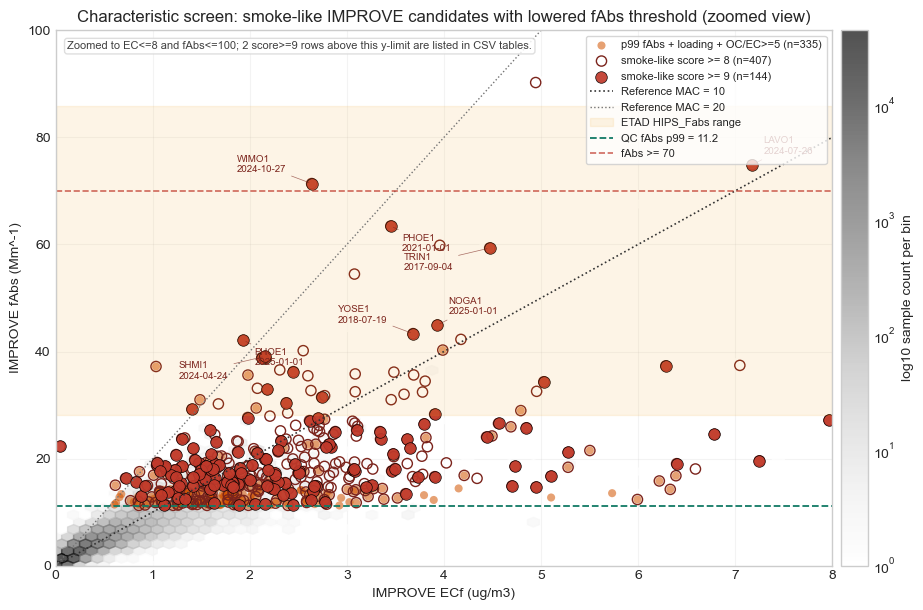

In [6]:
\
# Visualize characteristic-based candidates. This deliberately lowers the optical threshold from ETAD min to QC p99.
fig, ax = plt.subplots(figsize=(10, 6.2))
plot_bg = char[(char['ECf_Val'] <= 8) & (char['fAbs_Val'] <= 100)].copy()
hb = ax.hexbin(
    plot_bg['ECf_Val'], plot_bg['fAbs_Val'],
    gridsize=65, extent=(0, 8, 0, 100), mincnt=1, bins='log', cmap='Greys', alpha=0.68,
)
fig.colorbar(hb, ax=ax, pad=0.01, label='log10 sample count per bin')

loose = characteristic_groups['fAbs >= QC p99 + ETAD-low loading + OC/EC >= 5']
strong = characteristic_groups['smoke_like_score >= 8']
top = characteristic_groups['smoke_like_score >= 9']

ax.scatter(loose['ECf_Val'], loose['fAbs_Val'], s=34, color='#D35400', alpha=0.55, edgecolor='none', label=f'p99 fAbs + loading + OC/EC>=5 (n={len(loose)})')
ax.scatter(strong['ECf_Val'], strong['fAbs_Val'], s=54, facecolor='none', edgecolor='#7B241C', linewidth=1.0, label=f'smoke-like score >= 8 (n={len(strong)})')
ax.scatter(top['ECf_Val'], top['fAbs_Val'], s=70, color='#C0392B', alpha=0.92, edgecolor='black', linewidth=0.5, label=f'smoke-like score >= 9 (n={len(top)})')

visible_top = top[(top['ECf_Val'].between(0, 8)) & (top['fAbs_Val'].between(0, 100))].copy()
label_rows = visible_top.sort_values('fAbs_Val', ascending=False).head(8).reset_index(drop=True)
label_offsets = [(8, 8), (-54, 8), (8, -18), (-62, -16), (8, 8), (-54, 8), (8, -18), (-62, -16)]
for j, row in label_rows.iterrows():
    ax.annotate(
        f"{row['SiteCode']}\n{row['Date'].strftime('%Y-%m-%d')}",
        (row['ECf_Val'], row['fAbs_Val']),
        xytext=label_offsets[j % len(label_offsets)],
        textcoords='offset points',
        fontsize=7,
        color='#7B241C',
        arrowprops=dict(arrowstyle='-', color='#7B241C', lw=0.5, alpha=0.65),
    )

above_view = len(top[top['fAbs_Val'] > 100])
if above_view:
    ax.text(
        0.015, 0.98,
        f"Zoomed to EC<=8 and fAbs<=100; {above_view} score>=9 rows above this y-limit are listed in CSV tables.",
        transform=ax.transAxes, va='top', ha='left', fontsize=8, color='0.25',
        bbox=dict(boxstyle='round,pad=0.25', facecolor='white', edgecolor='0.85', alpha=0.85),
    )

x_line = np.linspace(0, 8, 200)
ax.plot(x_line, 10*x_line, color='0.20', lw=1.2, ls=':', label='Reference MAC = 10')
ax.plot(x_line, 20*x_line, color='0.45', lw=1.0, ls=':', label='Reference MAC = 20')
ax.axhspan(ETAD_FABS_MIN, ETAD_FABS_MAX, color='#F39C12', alpha=0.10, label='ETAD HIPS_Fabs range')
ax.axhline(smoke_thresholds['fAbs_p99'], color='#117A65', ls='--', lw=1.3, label=f"QC fAbs p99 = {smoke_thresholds['fAbs_p99']:.1f}")
ax.axhline(HIGH_TAIL_THRESHOLD, color='#C0392B', ls='--', lw=1.2, alpha=0.75, label=f'fAbs >= {HIGH_TAIL_THRESHOLD:g}')
ax.set_xlim(0, 8)
ax.set_ylim(0, 100)
ax.set_xlabel('IMPROVE ECf (ug/m3)')
ax.set_ylabel('IMPROVE fAbs (Mm^-1)')
ax.set_title('Characteristic screen: smoke-like IMPROVE candidates with lowered fAbs threshold (zoomed view)')
ax.grid(alpha=0.22)
ax.legend(loc='upper right', fontsize=8, frameon=True)
fig.tight_layout()
fig.savefig(OUT_DIR / 'improve_smoke_characteristic_candidates.png', dpi=240, bbox_inches='tight')
plt.show()


## 5. fAbs threshold sweep and interactive slider

The exact ETAD `fAbs` range is too sparse in IMPROVE, so this section treats the high-`fAbs` cutoff as a sensitivity parameter. For each threshold, it keeps rows with `fAbs >= threshold`, fits `fAbs = slope * ECf + intercept`, reports `R2`, and overlays a rolling/moving average across nearby thresholds.

Important caveat: selecting rows by the response variable (`fAbs`) can mechanically create high intercepts and unstable slopes. Use this as a threshold-sensitivity screen, not as proof of an Addis-like failure mode by itself.

In [7]:

# Threshold sweep for the high-fAbs tail. The fine step supports the notebook slider.
SWEEP_THRESHOLD_MIN = 5.0
SWEEP_THRESHOLD_MAX = 90.0
SWEEP_THRESHOLD_STEP = 0.25
SWEEP_MOVING_AVG_WINDOW = 9  # 9 * 0.25 = 2.25 Mm^-1 smoothing window

base_screen_all = char.copy()
base_screen_loading_ocec = char[char['char_high_loading'] & char['char_organic_rich']].copy()

threshold_sweep_bases = {
    'All QC + loading': base_screen_all,
    'ETAD-low loading + OC/EC>=5': base_screen_loading_ocec,
}

special_thresholds = np.array([
    smoke_thresholds['fAbs_p99'],
    smoke_thresholds['fAbs_p995'],
    ETAD_FABS_MIN,
    ETAD_FABS_MAX,
    HIGH_TAIL_THRESHOLD,
    ETAD_FABS_MAX,
], dtype=float)
regular_thresholds = np.arange(SWEEP_THRESHOLD_MIN, SWEEP_THRESHOLD_MAX + 1e-9, SWEEP_THRESHOLD_STEP)
threshold_grid = np.unique(np.round(np.concatenate([regular_thresholds, special_thresholds]), 4))
threshold_grid = threshold_grid[(threshold_grid >= SWEEP_THRESHOLD_MIN) & (threshold_grid <= max(SWEEP_THRESHOLD_MAX, np.nanmax(special_thresholds)))]


def fit_threshold_subset(base_df, threshold):
    subset = base_df[base_df['fAbs_Val'] >= threshold].copy()
    fit = regression_stats(subset, 'ECf_Val', 'fAbs_Val')
    return subset, fit


sweep_rows = []
for screen_name, base_df in threshold_sweep_bases.items():
    for threshold in threshold_grid:
        subset, fit = fit_threshold_subset(base_df, threshold)
        sweep_rows.append({
            'screen': screen_name,
            'fAbs_threshold': threshold,
            'n': fit['n'],
            'sites': subset['SiteCode'].nunique() if len(subset) else 0,
            'fAbs_min_kept': subset['fAbs_Val'].min() if len(subset) else np.nan,
            'fAbs_median_kept': subset['fAbs_Val'].median() if len(subset) else np.nan,
            'fAbs_max_kept': subset['fAbs_Val'].max() if len(subset) else np.nan,
            'EC_median_kept': subset['ECf_Val'].median() if len(subset) else np.nan,
            'slope': fit['slope'],
            'intercept': fit['intercept'],
            'r2': fit['r2'],
            'origin_mac': fit['origin_mac'],
            'equation': f"fAbs = {fit['slope']:.3g} * ECf + {fit['intercept']:.3g}; R2 = {fit['r2']:.3g}; n = {fit['n']}" if np.isfinite(fit['slope']) else f"insufficient data; n = {fit['n']}",
        })

threshold_sweep_stats = pd.DataFrame(sweep_rows).sort_values(['screen', 'fAbs_threshold']).reset_index(drop=True)
for metric in ['slope', 'intercept', 'r2', 'origin_mac', 'n']:
    threshold_sweep_stats[f'{metric}_ma'] = (
        threshold_sweep_stats
        .groupby('screen', group_keys=False)[metric]
        .apply(lambda s: s.rolling(SWEEP_MOVING_AVG_WINDOW, center=True, min_periods=2).mean())
    )

threshold_sweep_stats.to_csv(OUT_DIR / 'improve_fabs_threshold_sweep_stats.csv', index=False)

key_thresholds = np.array([
    5.0,
    7.5,
    10.0,
    smoke_thresholds['fAbs_p99'],
    smoke_thresholds['fAbs_p995'],
    20.0,
    ETAD_FABS_MIN,
    40.0,
    HIGH_TAIL_THRESHOLD,
    ETAD_FABS_MAX,
], dtype=float)
key_rows = []
for screen_name in threshold_sweep_bases:
    one = threshold_sweep_stats[threshold_sweep_stats['screen'] == screen_name].copy()
    for target in key_thresholds:
        idx = (one['fAbs_threshold'] - target).abs().idxmin()
        row = one.loc[idx].copy()
        row['requested_threshold'] = target
        key_rows.append(row)
threshold_sweep_key_thresholds = pd.DataFrame(key_rows)
threshold_sweep_key_thresholds.to_csv(OUT_DIR / 'improve_fabs_threshold_sweep_key_thresholds.csv', index=False)

display_cols = [
    'screen', 'requested_threshold', 'fAbs_threshold', 'n', 'sites',
    'slope', 'intercept', 'r2', 'origin_mac', 'equation'
]
display(threshold_sweep_key_thresholds[display_cols].round(3))


,screen,requested_threshold,fAbs_threshold,n,sites,slope,intercept,r2,origin_mac,equation
0,All QC + loading,5.000,5.000,9423,162,1.737,6.667,0.192,3.793,fAbs = 1.74 * ECf + 6.67; R2 = 0.192; n = 9423
10,All QC + loading,7.500,7.500,3688,144,1.209,10.183,0.111,3.370,fAbs = 1.21 * ECf + 10.2; R2 = 0.111; n = 3688
20,All QC + loading,10.000,10.000,1917,119,0.881,13.472,0.065,3.074,fAbs = 0.881 * ECf + 13.5; R2 = 0.0649; n = 1917
25,All QC + loading,11.220,11.220,1453,104,0.750,15.075,0.049,2.935,fAbs = 0.75 * ECf + 15.1; R2 = 0.0486; n = 1453
40,All QC + loading,14.550,14.550,726,78,0.576,19.313,0.028,2.738,fAbs = 0.576 * ECf + 19.3; R2 = 0.0279; n = 726
62,All QC + loading,20.000,20.000,242,58,0.332,28.310,0.008,2.532,fAbs = 0.332 * ECf + 28.3; R2 = 0.00787; n = 242
95,All QC + loading,28.086,28.086,78,28,0.213,42.619,0.002,2.855,fAbs = 0.213 * ECf + 42.6; R2 = 0.00199; n = 78
143,All QC + loading,40.000,40.000,21,11,2.752,58.462,0.033,9.648,fAbs = 2.75 * ECf + 58.5; R2 = 0.0334; n = 21
263,All QC + loading,70.000,70.000,5,4,19.769,24.051,0.232,23.205,fAbs = 19.8 * ECf + 24.1; R2 = 0.232; n = 5
327,All QC + loading,85.853,85.853,3,3,18.860,62.406,0.137,27.197,fAbs = 18.9 * ECf + 62.4; R2 = 0.137; n = 3


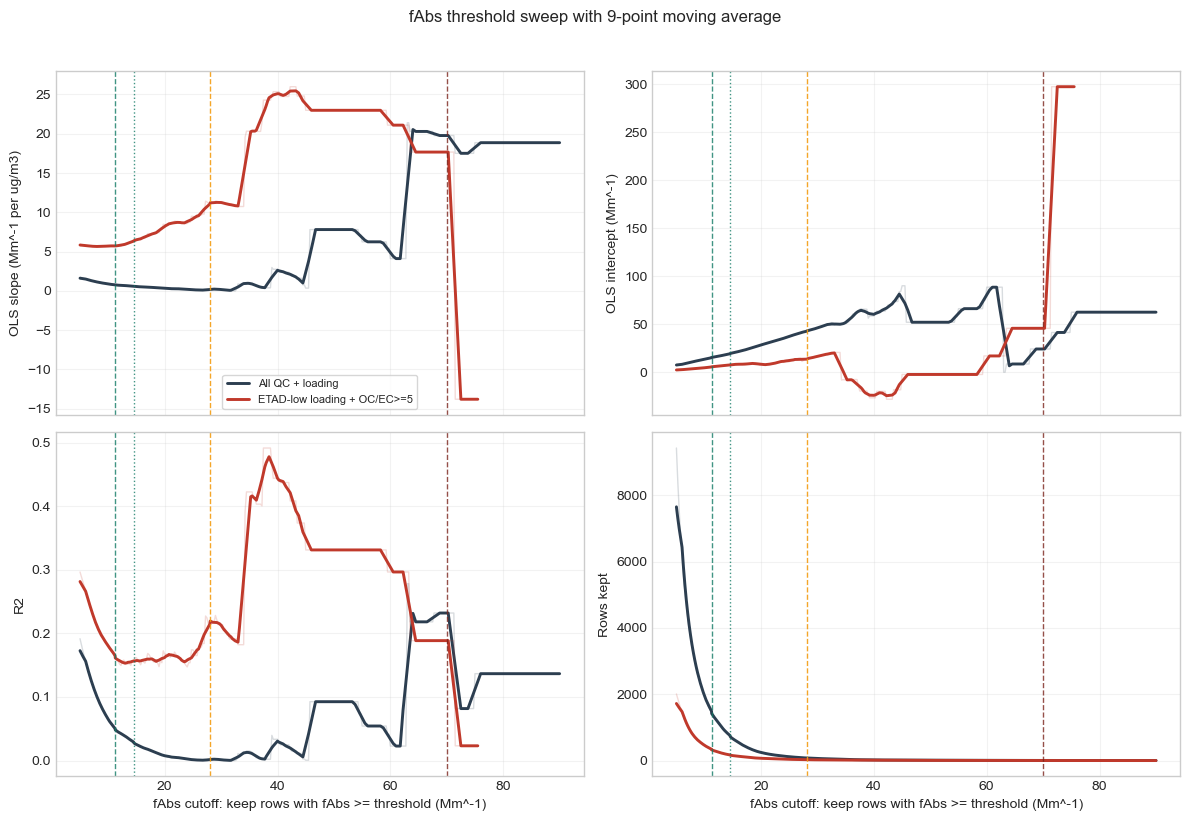

In [8]:

# Moving-average view: how slope/intercept/R2 change as the fAbs cutoff moves.
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
axes = axes.ravel()
metric_specs = [
    ('slope', 'OLS slope (Mm^-1 per ug/m3)'),
    ('intercept', 'OLS intercept (Mm^-1)'),
    ('r2', 'R2'),
    ('n', 'Rows kept'),
]
colors = {
    'All QC + loading': '#2C3E50',
    'ETAD-low loading + OC/EC>=5': '#C0392B',
}

for ax, (metric, label) in zip(axes, metric_specs):
    for screen_name, color in colors.items():
        one = threshold_sweep_stats[threshold_sweep_stats['screen'] == screen_name]
        ax.plot(one['fAbs_threshold'], one[metric], color=color, alpha=0.18, lw=1.0)
        ax.plot(one['fAbs_threshold'], one[f'{metric}_ma'], color=color, lw=2.1, label=screen_name)
    ax.axvline(smoke_thresholds['fAbs_p99'], color='#117A65', ls='--', lw=1.0, alpha=0.8)
    ax.axvline(smoke_thresholds['fAbs_p995'], color='#117A65', ls=':', lw=1.0, alpha=0.8)
    ax.axvline(ETAD_FABS_MIN, color='#F39C12', ls='--', lw=1.0, alpha=0.9)
    ax.axvline(HIGH_TAIL_THRESHOLD, color='#7B241C', ls='--', lw=1.0, alpha=0.8)
    ax.set_ylabel(label)
    ax.grid(alpha=0.25)

axes[-2].set_xlabel('fAbs cutoff: keep rows with fAbs >= threshold (Mm^-1)')
axes[-1].set_xlabel('fAbs cutoff: keep rows with fAbs >= threshold (Mm^-1)')
axes[0].legend(loc='best', fontsize=8, frameon=True)
fig.suptitle(f'fAbs threshold sweep with {SWEEP_MOVING_AVG_WINDOW}-point moving average', y=1.02)
fig.tight_layout()
fig.savefig(OUT_DIR / 'improve_fabs_threshold_sweep_moving_average.png', dpi=240, bbox_inches='tight')
plt.show()


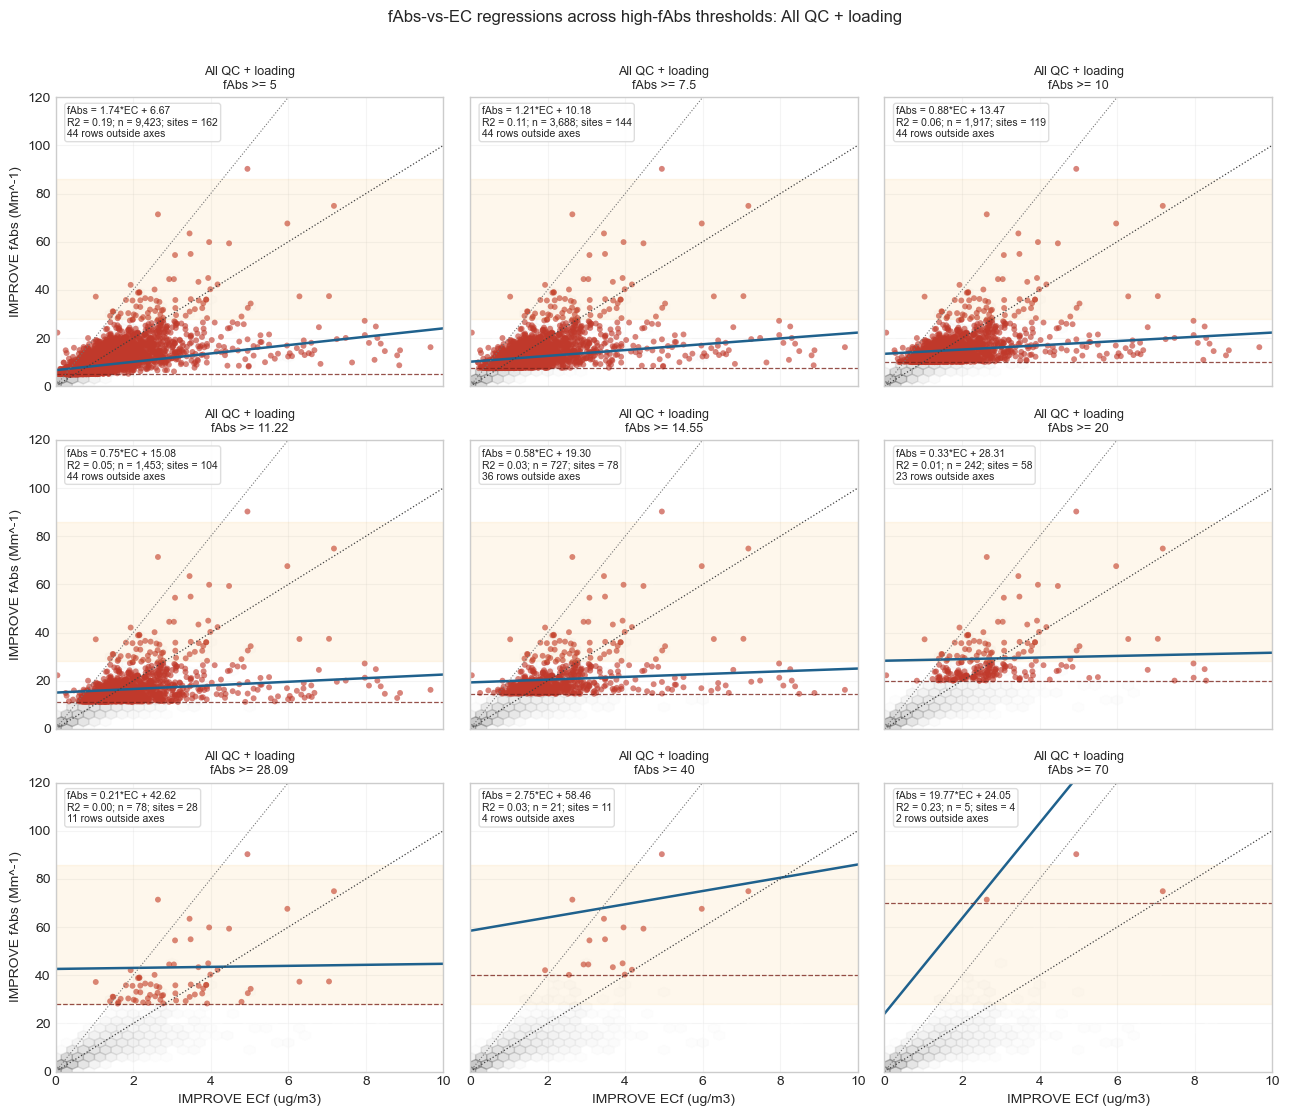

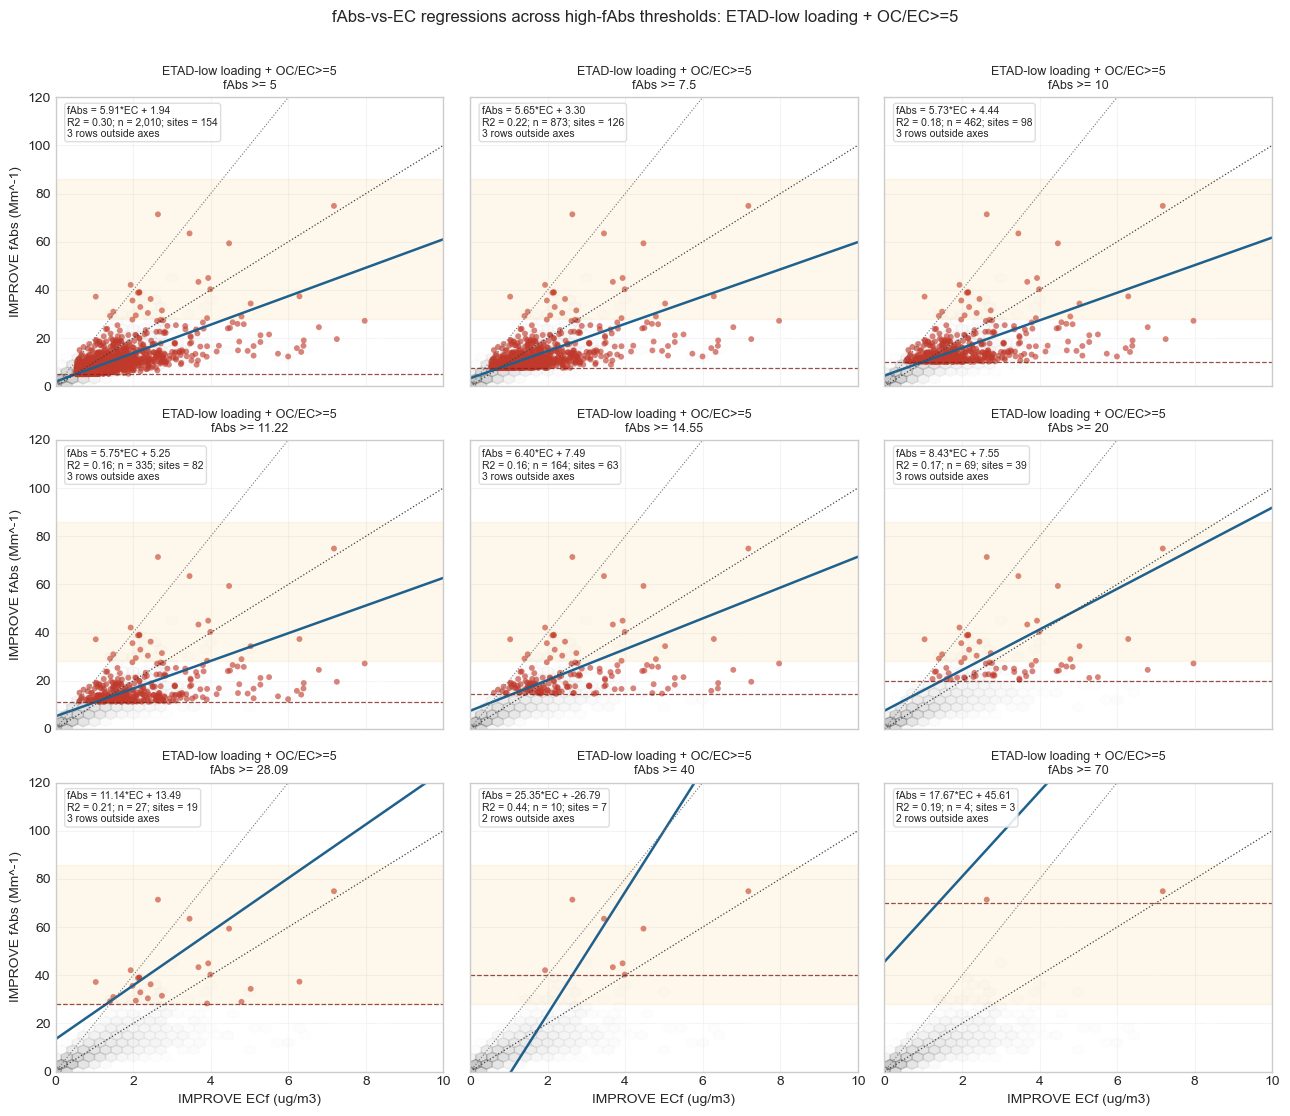

In [9]:

# Static graph grid for representative thresholds. The slider below is finer; this grid is for export/presentation.
representative_thresholds = [
    5.0,
    7.5,
    10.0,
    round(float(smoke_thresholds['fAbs_p99']), 2),
    round(float(smoke_thresholds['fAbs_p995']), 2),
    20.0,
    round(float(ETAD_FABS_MIN), 2),
    40.0,
    float(HIGH_TAIL_THRESHOLD),
]


def draw_threshold_fit(ax, base_df, threshold, screen_label, xlim=(0, 10), ylim=(0, 120), show_background=True):
    if show_background:
        bg = char[(char['ECf_Val'].between(*xlim)) & (char['fAbs_Val'].between(*ylim))]
        ax.hexbin(
            bg['ECf_Val'], bg['fAbs_Val'], gridsize=35,
            extent=(xlim[0], xlim[1], ylim[0], ylim[1]), mincnt=1,
            bins='log', cmap='Greys', alpha=0.22,
        )
    subset, fit = fit_threshold_subset(base_df, threshold)
    plot_subset = subset[(subset['ECf_Val'].between(*xlim)) & (subset['fAbs_Val'].between(*ylim))]
    ax.scatter(plot_subset['ECf_Val'], plot_subset['fAbs_Val'], s=18, color='#C0392B', alpha=0.62, edgecolor='none')
    if np.isfinite(fit['slope']):
        x_line = np.linspace(xlim[0], xlim[1], 200)
        ax.plot(x_line, fit['slope'] * x_line + fit['intercept'], color='#1F618D', lw=1.8)
        label = f"fAbs = {fit['slope']:.2f}*EC + {fit['intercept']:.2f}\nR2 = {fit['r2']:.2f}; n = {fit['n']:,}; sites = {subset['SiteCode'].nunique()}"
    else:
        label = f"insufficient data\nn = {fit['n']:,}; sites = {subset['SiteCode'].nunique()}"
    clipped = len(subset) - len(plot_subset)
    if clipped > 0:
        label += f"\n{clipped:,} rows outside axes"
    ax.text(0.03, 0.97, label, transform=ax.transAxes, va='top', ha='left', fontsize=7.5,
            bbox=dict(boxstyle='round,pad=0.25', facecolor='white', edgecolor='0.85', alpha=0.88))
    ax.axhline(threshold, color='#7B241C', ls='--', lw=0.9, alpha=0.8)
    ax.axhspan(ETAD_FABS_MIN, ETAD_FABS_MAX, color='#F39C12', alpha=0.08)
    ax.plot(np.linspace(*xlim, 100), 10*np.linspace(*xlim, 100), color='0.25', ls=':', lw=0.9)
    ax.plot(np.linspace(*xlim, 100), 20*np.linspace(*xlim, 100), color='0.45', ls=':', lw=0.8)
    ax.set_title(f'{screen_label}\nfAbs >= {threshold:g}', fontsize=9)
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.grid(alpha=0.20)


def save_threshold_grid(screen_name, base_df, filename, xlim=(0, 10), ylim=(0, 120)):
    fig, axes = plt.subplots(3, 3, figsize=(13, 11), sharex=True, sharey=True)
    for ax, threshold in zip(axes.ravel(), representative_thresholds):
        draw_threshold_fit(ax, base_df, threshold, screen_name, xlim=xlim, ylim=ylim)
    for ax in axes[-1, :]:
        ax.set_xlabel('IMPROVE ECf (ug/m3)')
    for ax in axes[:, 0]:
        ax.set_ylabel('IMPROVE fAbs (Mm^-1)')
    fig.suptitle(f'fAbs-vs-EC regressions across high-fAbs thresholds: {screen_name}', y=1.01)
    fig.tight_layout()
    fig.savefig(OUT_DIR / filename, dpi=240, bbox_inches='tight')
    plt.show()

save_threshold_grid('All QC + loading', base_screen_all, 'improve_fabs_threshold_fit_grid_all_qc.png')
save_threshold_grid('ETAD-low loading + OC/EC>=5', base_screen_loading_ocec, 'improve_fabs_threshold_fit_grid_loading_ocec.png')


In [10]:

# Interactive threshold slider. Run this cell in Jupyter to inspect any cutoff at 0.25 Mm^-1 resolution.
try:
    import ipywidgets as widgets

    def plot_fabs_threshold_slider(screen='All QC + loading', threshold=float(smoke_thresholds['fAbs_p99']), x_max=10.0, y_max=120.0):
        base_df = threshold_sweep_bases[screen]
        subset, fit = fit_threshold_subset(base_df, threshold)
        fig, ax = plt.subplots(figsize=(8.8, 5.7))
        draw_threshold_fit(
            ax,
            base_df,
            threshold,
            screen,
            xlim=(0, float(x_max)),
            ylim=(0, float(y_max)),
            show_background=True,
        )
        ax.set_xlabel('IMPROVE ECf (ug/m3)')
        ax.set_ylabel('IMPROVE fAbs (Mm^-1)')
        ax.set_title(f'{screen}: fAbs >= {threshold:.2f} Mm^-1')
        plt.show()
        if np.isfinite(fit['slope']):
            print(f"Equation: fAbs = {fit['slope']:.4f} * ECf + {fit['intercept']:.4f}")
            print(f"R2 = {fit['r2']:.4f}; origin MAC = {fit['origin_mac']:.4f}; n = {fit['n']:,}; sites = {subset['SiteCode'].nunique()}")
        else:
            print(f"Insufficient data for regression: n = {fit['n']:,}; sites = {subset['SiteCode'].nunique()}")

    threshold_slider = widgets.FloatSlider(
        value=float(smoke_thresholds['fAbs_p99']),
        min=SWEEP_THRESHOLD_MIN,
        max=SWEEP_THRESHOLD_MAX,
        step=SWEEP_THRESHOLD_STEP,
        description='fAbs cutoff',
        readout_format='.2f',
        continuous_update=False,
        style={'description_width': 'initial'},
        layout=widgets.Layout(width='520px'),
    )
    screen_dropdown = widgets.Dropdown(
        options=list(threshold_sweep_bases.keys()),
        value='All QC + loading',
        description='screen',
        style={'description_width': 'initial'},
        layout=widgets.Layout(width='320px'),
    )
    x_slider = widgets.FloatSlider(value=10.0, min=4.0, max=20.0, step=1.0, description='x max', continuous_update=False)
    y_slider = widgets.FloatSlider(value=120.0, min=40.0, max=320.0, step=20.0, description='y max', continuous_update=False)

    ui = widgets.VBox([screen_dropdown, threshold_slider, widgets.HBox([x_slider, y_slider])])
    out = widgets.interactive_output(
        plot_fabs_threshold_slider,
        {'screen': screen_dropdown, 'threshold': threshold_slider, 'x_max': x_slider, 'y_max': y_slider},
    )
    display(ui, out)
except Exception as exc:
    print(f'Interactive slider unavailable in this environment: {exc}')
    print('Use improve_fabs_threshold_sweep_stats.csv and the saved threshold grid figures instead.')


Output()

## 6. Regression comparison after ETAD-style filtering

This section mirrors the cross-method baseline logic from `hips_offset_narrative.ipynb`, but with the group definitions corrected for the IMPROVE question. The loading-matched rows are the main comparison. The fAbs-selected rows are shown as a descriptive boundary test, not as an inferential regression target.


,group,n,slope,intercept,r2,origin_mac,site_count,fAbs_median,EC_median
0,all_positive_ec_fabs,379697,5.367,1.142,0.567,6.704,214,1.51,0.121
1,rt_and_loading_available,145200,3.559,1.299,0.395,4.595,167,1.30,0.106
2,ETAD_loading_p05p95,6946,6.918,1.694,0.508,8.450,158,7.10,0.780
3,ETAD_loading_IQR,2855,8.011,0.660,0.272,8.597,152,8.62,1.016
4,ETAD_fAbs_only_with_qc,75,0.019,37.639,0.000,2.290,28,34.46,3.078
5,ETAD_fAbs_plus_ETAD_loading,24,5.404,24.090,0.134,16.279,14,33.02,2.040
6,ETAD_fAbs_plus_ETAD_loading_IQR,9,22.265,-0.754,0.602,21.849,8,31.11,1.620
7,fAbs_ge70_plus_ETAD_loading,1,NaN,NaN,NaN,NaN,1,71.38,2.638


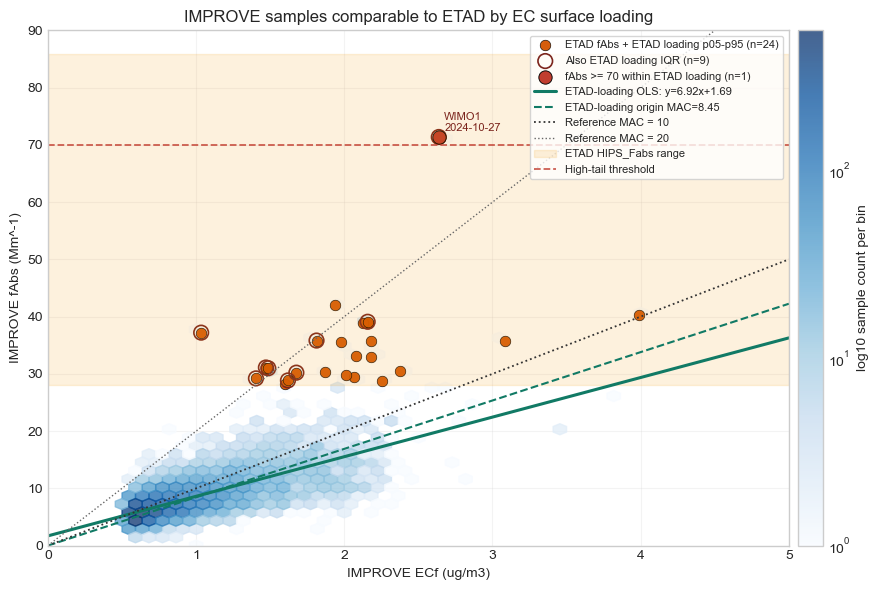

In [11]:
\
fit_groups = {
    'all_positive_ec_fabs': valid,
    'rt_and_loading_available': qc,
    'ETAD_loading_p05p95': loading_matched,
    'ETAD_loading_IQR': loading_iqr,
    'ETAD_fAbs_only_with_qc': fabs_matched,
    'ETAD_fAbs_plus_ETAD_loading': both_matched,
    'ETAD_fAbs_plus_ETAD_loading_IQR': both_iqr,
    'fAbs_ge70_plus_ETAD_loading': high_tail_loading,
}
fit_summary = display_fit_table(fit_groups)
fit_summary.to_csv(OUT_DIR / 'improve_fabs_vs_ec_fit_summary.csv', index=False)
display(fit_summary.round(3))

fig, ax = plt.subplots(figsize=(9.5, 6.0))
plot_bg = loading_matched[(loading_matched['ECf_Val'] <= 5.0) & (loading_matched['fAbs_Val'] <= 90.0)].copy()
hb = ax.hexbin(
    plot_bg['ECf_Val'], plot_bg['fAbs_Val'],
    gridsize=55, extent=(0, 5, 0, 90), mincnt=1, bins='log', cmap='Blues', alpha=0.75,
)
cbar = fig.colorbar(hb, ax=ax, pad=0.01)
cbar.set_label('log10 sample count per bin')

ax.scatter(both_matched['ECf_Val'], both_matched['fAbs_Val'], s=58, color='#D35400', alpha=0.95, edgecolor='black', linewidth=0.45, label=f'ETAD fAbs + ETAD loading p05-p95 (n={len(both_matched)})')
ax.scatter(both_iqr['ECf_Val'], both_iqr['fAbs_Val'], s=110, facecolor='none', edgecolor='#7B241C', linewidth=1.2, label=f'Also ETAD loading IQR (n={len(both_iqr)})')
if len(high_tail_loading):
    ax.scatter(high_tail_loading['ECf_Val'], high_tail_loading['fAbs_Val'], s=92, color='#C0392B', alpha=0.98, edgecolor='black', linewidth=0.65, label=f'fAbs >= {HIGH_TAIL_THRESHOLD:g} within ETAD loading (n={len(high_tail_loading)})')
    for _, row in high_tail_loading.iterrows():
        ax.annotate(f"{row['SiteCode']}\n{row['Date'].strftime('%Y-%m-%d')}", (row['ECf_Val'], row['fAbs_Val']), xytext=(4, 4), textcoords='offset points', fontsize=8, color='#7B241C')

fit = regression_stats(loading_matched, 'ECf_Val', 'fAbs_Val')
x_line = np.linspace(0, 5, 200)
ax.plot(x_line, fit['slope'] * x_line + fit['intercept'], color='#117A65', lw=2.2, label=f"ETAD-loading OLS: y={fit['slope']:.2f}x+{fit['intercept']:.2f}")
ax.plot(x_line, fit['origin_mac'] * x_line, color='#117A65', lw=1.5, ls='--', label=f"ETAD-loading origin MAC={fit['origin_mac']:.2f}")
ax.plot(x_line, 10*x_line, color='0.20', lw=1.3, ls=':', label='Reference MAC = 10')
ax.plot(x_line, 20*x_line, color='0.40', lw=1.0, ls=':', label='Reference MAC = 20')
ax.axhspan(ETAD_FABS_MIN, ETAD_FABS_MAX, color='#F39C12', alpha=0.14, label='ETAD HIPS_Fabs range')
ax.axhline(HIGH_TAIL_THRESHOLD, color='#C0392B', ls='--', lw=1.3, alpha=0.8, label='High-tail threshold')
ax.set_xlim(0, 5)
ax.set_ylim(0, 90)
ax.set_xlabel('IMPROVE ECf (ug/m3)')
ax.set_ylabel('IMPROVE fAbs (Mm^-1)')
ax.set_title('IMPROVE samples comparable to ETAD by EC surface loading')
ax.grid(alpha=0.22)
ax.legend(loc='upper right', fontsize=8, frameon=True)
fig.tight_layout()
fig.savefig(OUT_DIR / 'improve_etad_loading_fabs_vs_ec.png', dpi=240, bbox_inches='tight')
plt.show()


## 7. IMPROVE optical-regime diagnostics from RT fields

This mirrors the raw T/R geometry section of the Addis notebook, with one caveat: the IMPROVE FED fields are final/initial/minimum reflectance and transmittance ratios at 635 nm, not the same local SPARTAN `T1/R1` fields. Therefore these figures are diagnostic proxies, not a direct SOP-276 tau recalculation.


,group,n,sites,trans_min_over_initial_median,trans_min_over_initial_p90,ref_min_over_initial_median,ref_min_over_initial_p90,rt_sum_min_over_initial_median,rt_sum_min_over_initial_p90,trans_od_proxy_median,trans_od_proxy_p90,fAbs_Val_median,fAbs_Val_p90,ECf_Val_median,ECf_Val_p90,EC_loading_ug_cm2_area_3p5_median,EC_loading_ug_cm2_area_3p5_p90,OC_EC_median,OC_EC_p90
0,RT+loading available,145200,167,0.4451,0.7912,0.8527,0.9496,0.7259,0.8960,0.8095,2.1540,1.30,4.130,0.1057,0.3734,0.9201,3.2493,5.6386,12.5206
1,ETAD loading p05-p95,6946,158,0.1484,0.4910,0.8557,0.9462,0.7213,0.8943,1.9081,5.4580,7.10,13.000,0.7799,1.5465,6.7473,13.0601,3.8639,9.9546
2,ETAD fAbs + loading,24,14,0.1732,0.5366,0.9112,0.9414,0.8859,0.9251,1.7569,20.7233,33.02,39.919,2.0395,2.5595,16.2577,18.9217,5.9634,13.4672
3,fAbs>=70 + loading,1,1,0.0000,0.0000,0.8463,0.8463,0.8328,0.8328,20.7233,20.7233,71.38,71.380,2.6376,2.6376,11.8592,11.8592,14.8495,14.8495


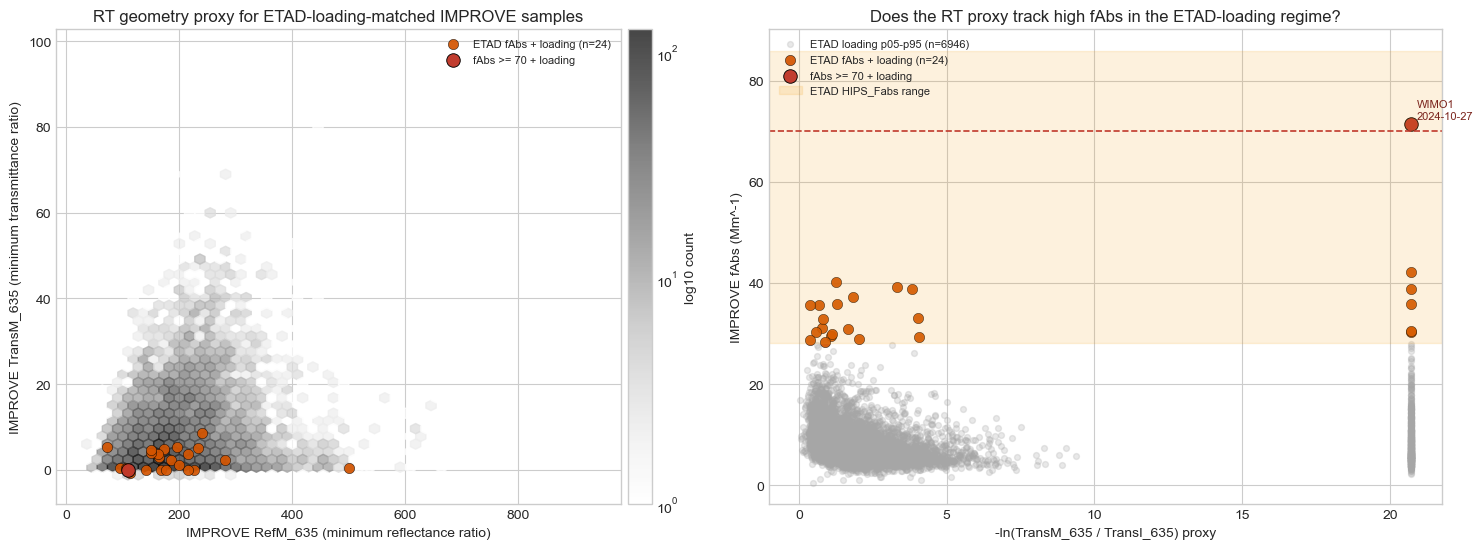

Spearman correlation within ETAD-loading-matched samples: rho=-0.308, p=3.48e-152


In [12]:
\
rt_metrics = ['trans_min_over_initial', 'ref_min_over_initial', 'rt_sum_min_over_initial', 'trans_od_proxy']
context_groups = {
    'RT+loading available': qc,
    'ETAD loading p05-p95': loading_matched,
    'ETAD fAbs + loading': both_matched,
    'fAbs>=70 + loading': high_tail_loading,
}
rt_rows = []
for name, g in context_groups.items():
    row = {'group': name, 'n': len(g), 'sites': g['SiteCode'].nunique() if len(g) else 0}
    for col in rt_metrics + ['fAbs_Val', 'ECf_Val', 'EC_loading_ug_cm2_area_3p5', 'OC_EC']:
        row[f'{col}_median'] = g[col].median() if col in g and len(g) else np.nan
        row[f'{col}_p90'] = g[col].quantile(0.90) if col in g and len(g) else np.nan
    rt_rows.append(row)
rt_summary = pd.DataFrame(rt_rows)
rt_summary.to_csv(OUT_DIR / 'improve_rt_optical_regime_summary.csv', index=False)
display(rt_summary.round(4))

fig, axes = plt.subplots(1, 2, figsize=(15, 5.6))

# A. T/R geometry proxy: minimum transmittance vs minimum reflectance.
ax = axes[0]
bg = loading_matched.dropna(subset=['RefM_635_Val', 'TransM_635_Val'])
hb = ax.hexbin(bg['RefM_635_Val'], bg['TransM_635_Val'], gridsize=50, mincnt=1, bins='log', cmap='Greys', alpha=0.72)
fig.colorbar(hb, ax=ax, pad=0.01, label='log10 count')
ax.scatter(both_matched['RefM_635_Val'], both_matched['TransM_635_Val'], s=55, color='#D35400', edgecolor='black', linewidth=0.35, alpha=0.92, label=f'ETAD fAbs + loading (n={len(both_matched)})')
if len(high_tail_loading):
    ax.scatter(high_tail_loading['RefM_635_Val'], high_tail_loading['TransM_635_Val'], s=95, color='#C0392B', edgecolor='black', linewidth=0.65, alpha=0.98, label=f'fAbs >= {HIGH_TAIL_THRESHOLD:g} + loading')
ax.set_xlabel('IMPROVE RefM_635 (minimum reflectance ratio)')
ax.set_ylabel('IMPROVE TransM_635 (minimum transmittance ratio)')
ax.set_title('RT geometry proxy for ETAD-loading-matched IMPROVE samples')
ax.legend(fontsize=8)

# B. Optical-depth proxy vs fAbs.
ax = axes[1]
bg2 = loading_matched.dropna(subset=['trans_od_proxy', 'fAbs_Val'])
ax.scatter(bg2['trans_od_proxy'], bg2['fAbs_Val'], s=18, color='0.65', alpha=0.25, label=f'ETAD loading p05-p95 (n={len(bg2)})')
ax.scatter(both_matched['trans_od_proxy'], both_matched['fAbs_Val'], s=55, color='#D35400', edgecolor='black', linewidth=0.35, alpha=0.92, label=f'ETAD fAbs + loading (n={len(both_matched)})')
if len(high_tail_loading):
    ax.scatter(high_tail_loading['trans_od_proxy'], high_tail_loading['fAbs_Val'], s=95, color='#C0392B', edgecolor='black', linewidth=0.65, alpha=0.98, label=f'fAbs >= {HIGH_TAIL_THRESHOLD:g} + loading')
for _, row in high_tail_loading.iterrows():
    ax.annotate(f"{row['SiteCode']}\n{row['Date'].strftime('%Y-%m-%d')}", (row['trans_od_proxy'], row['fAbs_Val']), xytext=(4, 4), textcoords='offset points', fontsize=8, color='#7B241C')
ax.axhspan(ETAD_FABS_MIN, ETAD_FABS_MAX, color='#F39C12', alpha=0.14, label='ETAD HIPS_Fabs range')
ax.axhline(HIGH_TAIL_THRESHOLD, color='#C0392B', ls='--', lw=1.2)
ax.set_xlabel('-ln(TransM_635 / TransI_635) proxy')
ax.set_ylabel('IMPROVE fAbs (Mm^-1)')
ax.set_title('Does the RT proxy track high fAbs in the ETAD-loading regime?')
ax.legend(fontsize=8)

fig.tight_layout()
fig.savefig(OUT_DIR / 'improve_rt_geometry_proxy.png', dpi=240, bbox_inches='tight')
plt.show()

if len(bg2) >= 3:
    spearman = stats.spearmanr(bg2['trans_od_proxy'], bg2['fAbs_Val'], nan_policy='omit')
    print(f"Spearman correlation within ETAD-loading-matched samples: rho={spearman.statistic:.3f}, p={spearman.pvalue:.2e}")


## 8. IMPROVE T-vs-R initial-line diagnostic

This is the closest IMPROVE analog to the SPARTAN `T1` vs `R1` blank-regression diagnostic in `hips_offset_narrative.ipynb`.

It is **not exactly the same diagnostic** because the FED export does not include SPARTAN-style raw `T1/R1` values, field blanks, or lot-specific `a0/a1` HIPS coefficients. Instead, IMPROVE provides `RefI/TransI` and loaded-filter `RefM/TransM`/`RefF/TransF` fields. The defensible analog is:

- fit an empirical clean-filter line with `TransI_635 = b0 + b1 * RefI_635`
- compare loaded `TransM_635` to the expected `TransM` value from that initial line at the same `RefM_635`
- interpret the vertical gap as an IMPROVE RT displacement proxy, not as SPARTAN `tau` itself

The current FED `Data` sheets do **not** include explicit field-blank rows or a row-level sample-type flag. They only expose ambient IMPAER rows with `POC`/`AuxID`, plus metadata notes saying blanks were used internally for processing. Therefore this section does not separate blanks; `RefI/TransI` are used as the initial clean-filter state for each ambient sample.

Initial RT line: TransI_635 = 63.09 + 0.311 * RefI_635; R2=0.239; n=139,719


,group,n,sites,TransM_deficit_pct_vs_initial_line_median,TransM_deficit_pct_vs_initial_line_p90,TransF_deficit_pct_vs_initial_line_median,TransF_deficit_pct_vs_initial_line_p90,trans_min_over_initial_median,trans_min_over_initial_p90,ref_min_over_initial_median,ref_min_over_initial_p90,fAbs_Val_median,fAbs_Val_p90,ECf_Val_median,ECf_Val_p90,OC_EC_median,OC_EC_p90,TransM_deficit_vs_fAbs_r
0,QC all RT + loading,145200,167,54.698,91.653,-19.286,28.516,0.445,0.791,0.853,0.950,1.30,4.130,0.106,0.373,5.639,12.521,0.466
1,ETAD loading p05-p95,6946,158,94.344,99.814,-17.888,29.243,0.148,0.491,0.856,0.946,7.10,13.000,0.780,1.546,3.864,9.955,0.144
2,ETAD fAbs + loading,24,14,98.710,100.000,-12.821,32.109,0.173,0.537,0.911,0.941,33.02,39.919,2.040,2.559,5.963,13.467,0.300
3,fAbs>=70 + ETAD loading,1,1,100.000,100.000,-7.796,-7.796,0.000,0.000,0.846,0.846,71.38,71.380,2.638,2.638,14.850,14.850,NaN
4,smoke_like_score >= 8,407,85,99.796,100.000,-12.217,30.288,0.013,0.170,0.889,0.961,17.41,32.178,2.251,5.059,7.365,14.143,0.105
5,smoke_like_score >= 9,144,61,99.715,100.000,-12.064,29.936,0.019,0.136,0.865,0.934,18.12,34.248,2.170,4.725,12.085,17.051,0.132


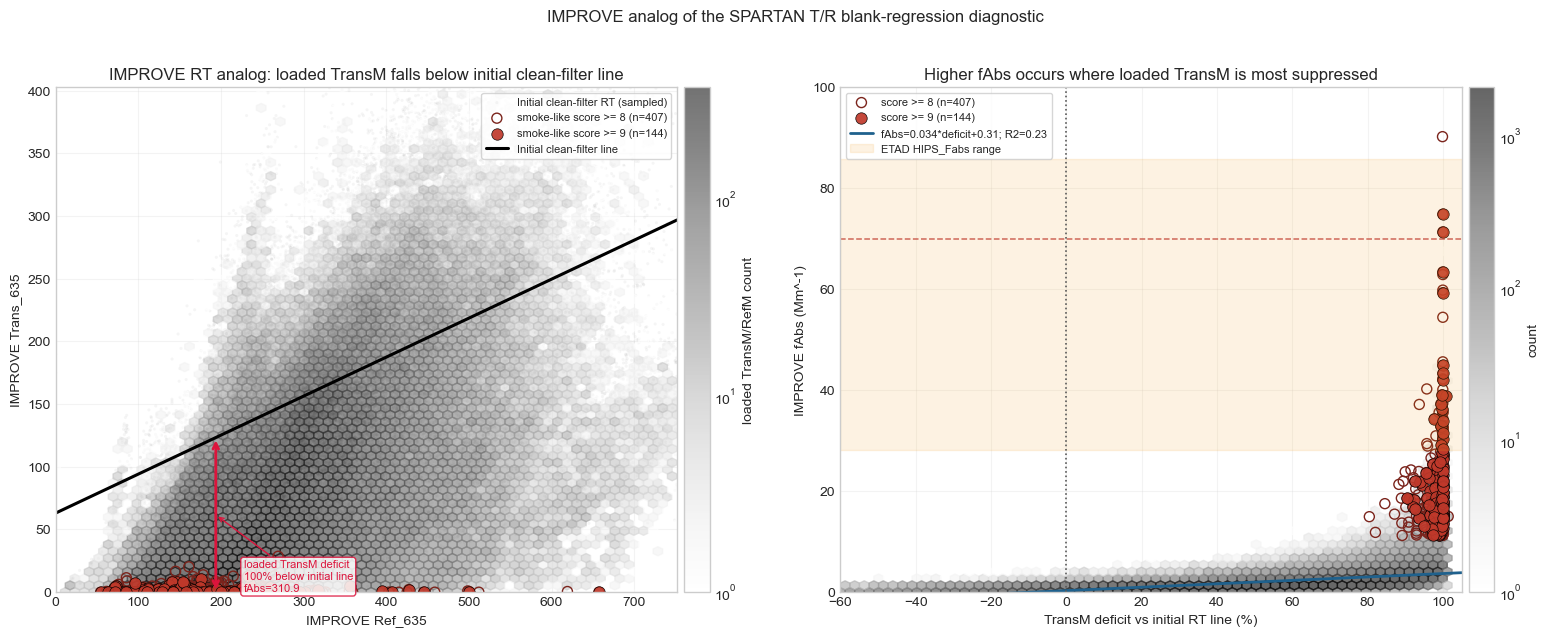

In [13]:

# IMPROVE analog to the SPARTAN T-vs-R blank-line diagnostic.
# Here the initial clean-filter line replaces the SPARTAN field-blank calibration line.
rt_line_fit_df = qc[['RefI_635_Val', 'TransI_635_Val']].replace([np.inf, -np.inf], np.nan).dropna().copy()
rt_line_fit_df = rt_line_fit_df[(rt_line_fit_df['RefI_635_Val'] > 0) & (rt_line_fit_df['TransI_635_Val'] > 0)]

# Clip the most extreme 1% tails before fitting the empirical initial line.
# This avoids a handful of instrument/export extremes controlling the line.
ref_i_lo, ref_i_hi = rt_line_fit_df['RefI_635_Val'].quantile([0.01, 0.99])
trans_i_lo, trans_i_hi = rt_line_fit_df['TransI_635_Val'].quantile([0.01, 0.99])
rt_line_fit_clip = rt_line_fit_df[
    rt_line_fit_df['RefI_635_Val'].between(ref_i_lo, ref_i_hi)
    & rt_line_fit_df['TransI_635_Val'].between(trans_i_lo, trans_i_hi)
].copy()

rt_initial_slope, rt_initial_intercept, rt_initial_r, rt_initial_p, rt_initial_se = stats.linregress(
    rt_line_fit_clip['RefI_635_Val'], rt_line_fit_clip['TransI_635_Val']
)
rt_initial_fit = {
    'n_fit': len(rt_line_fit_clip),
    'intercept': rt_initial_intercept,
    'slope': rt_initial_slope,
    'r2': rt_initial_r**2,
    'ref_i_lo_clip': ref_i_lo,
    'ref_i_hi_clip': ref_i_hi,
    'trans_i_lo_clip': trans_i_lo,
    'trans_i_hi_clip': trans_i_hi,
}
pd.DataFrame([rt_initial_fit]).to_csv(OUT_DIR / 'improve_rt_initial_line_fit.csv', index=False)
print(
    f"Initial RT line: TransI_635 = {rt_initial_intercept:.2f} + "
    f"{rt_initial_slope:.3f} * RefI_635; R2={rt_initial_r**2:.3f}; n={len(rt_line_fit_clip):,}"
)


def add_initial_line_metrics(df):
    g = df.copy()
    for phase, label in [('M', 'minimum'), ('F', 'final')]:
        ref_col = f'Ref{phase}_635_Val'
        trans_col = f'Trans{phase}_635_Val'
        expected_col = f'Trans{phase}_expected_initial_line'
        deficit_col = f'Trans{phase}_deficit_pct_vs_initial_line'
        ratio_col = f'Trans{phase}_over_expected_initial_line'
        g[expected_col] = rt_initial_intercept + rt_initial_slope * g[ref_col]
        g[ratio_col] = np.where(g[expected_col] > 0, g[trans_col] / g[expected_col], np.nan)
        g[deficit_col] = (1 - g[ratio_col]) * 100
    return g

qc_rtline = add_initial_line_metrics(qc)
loading_matched_rtline = add_initial_line_metrics(loading_matched)
both_matched_rtline = add_initial_line_metrics(both_matched)
high_tail_loading_rtline = add_initial_line_metrics(high_tail_loading)
char_rtline = add_initial_line_metrics(char)

rtline_groups = {
    'QC all RT + loading': qc_rtline,
    'ETAD loading p05-p95': loading_matched_rtline,
    'ETAD fAbs + loading': both_matched_rtline,
    'fAbs>=70 + ETAD loading': high_tail_loading_rtline,
    'smoke_like_score >= 8': char_rtline[char_rtline['smoke_like_score'] >= 8],
    'smoke_like_score >= 9': char_rtline[char_rtline['smoke_like_score'] >= 9],
}

rtline_summary_rows = []
for name, g in rtline_groups.items():
    row = {'group': name, 'n': len(g), 'sites': g['SiteCode'].nunique() if len(g) else 0}
    for col in [
        'TransM_deficit_pct_vs_initial_line',
        'TransF_deficit_pct_vs_initial_line',
        'trans_min_over_initial',
        'ref_min_over_initial',
        'fAbs_Val',
        'ECf_Val',
        'OC_EC',
    ]:
        row[f'{col}_median'] = g[col].median() if len(g) and col in g else np.nan
        row[f'{col}_p90'] = g[col].quantile(0.90) if len(g) and col in g else np.nan
    pair = g[['TransM_deficit_pct_vs_initial_line', 'fAbs_Val']].replace([np.inf, -np.inf], np.nan).dropna() if len(g) else pd.DataFrame()
    row['TransM_deficit_vs_fAbs_r'] = pair['TransM_deficit_pct_vs_initial_line'].corr(pair['fAbs_Val']) if len(pair) >= 3 else np.nan
    rtline_summary_rows.append(row)

rtline_summary = pd.DataFrame(rtline_summary_rows)
rtline_summary.to_csv(OUT_DIR / 'improve_rt_initial_line_diagnostic_summary.csv', index=False)
display(rtline_summary.round(3))

rtline_candidate_cols = [c for c in [
    'SiteCode', 'SiteName', 'State', 'Date', 'POC', 'AuxID',
    'ECf_Val', 'OCf_Val', 'fAbs_Val', 'OC_EC', 'MF_Val',
    'RefI_635_Val', 'TransI_635_Val', 'RefM_635_Val', 'TransM_635_Val',
    'TransM_expected_initial_line', 'TransM_deficit_pct_vs_initial_line',
    'TransM_over_expected_initial_line', 'trans_min_over_initial',
    'smoke_like_score',
] if c in char_rtline.columns]
char_rtline.sort_values(['smoke_like_score', 'fAbs_Val'], ascending=[False, False])[rtline_candidate_cols].head(250).to_csv(
    OUT_DIR / 'improve_rt_initial_line_top_candidates.csv', index=False
)

# Main two-panel analog to the SPARTAN diagnostic.
fig, axes = plt.subplots(1, 2, figsize=(16, 6.2))

# Left panel: initial clean-filter line, loaded minimum points, and vertical displacement example.
ax = axes[0]
xmax = np.nanpercentile(np.concatenate([qc_rtline['RefI_635_Val'].to_numpy(), qc_rtline['RefM_635_Val'].to_numpy()]), 99.5)
ymax = np.nanpercentile(np.concatenate([qc_rtline['TransI_635_Val'].to_numpy(), qc_rtline['TransM_635_Val'].to_numpy()]), 99.5)
xmax = max(650, min(xmax, 900))
ymax = max(360, min(ymax, 520))

initial_sample = qc_rtline.sample(min(len(qc_rtline), 45000), random_state=11)
ax.scatter(initial_sample['RefI_635_Val'], initial_sample['TransI_635_Val'], s=5, color='0.55', alpha=0.08, edgecolor='none', label='Initial clean-filter RT (sampled)')
loaded_bg = qc_rtline[(qc_rtline['RefM_635_Val'].between(0, xmax)) & (qc_rtline['TransM_635_Val'].between(0, ymax))]
hb = ax.hexbin(
    loaded_bg['RefM_635_Val'], loaded_bg['TransM_635_Val'],
    gridsize=65, extent=(0, xmax, 0, ymax), mincnt=1, bins='log', cmap='Greys', alpha=0.55,
)
fig.colorbar(hb, ax=ax, pad=0.01, label='loaded TransM/RefM count')

strong_rt = char_rtline[char_rtline['smoke_like_score'] >= 8]
top_rt = char_rtline[char_rtline['smoke_like_score'] >= 9]
ax.scatter(strong_rt['RefM_635_Val'], strong_rt['TransM_635_Val'], s=52, facecolor='none', edgecolor='#7B241C', linewidth=1.0, label=f'smoke-like score >= 8 (n={len(strong_rt)})')
ax.scatter(top_rt['RefM_635_Val'], top_rt['TransM_635_Val'], s=68, color='#C0392B', edgecolor='black', linewidth=0.5, alpha=0.92, label=f'smoke-like score >= 9 (n={len(top_rt)})')

x_line = np.linspace(0, xmax, 200)
y_line = rt_initial_intercept + rt_initial_slope * x_line
ax.plot(x_line, y_line, color='black', lw=2.2, label='Initial clean-filter line')

visible_examples = top_rt[
    top_rt['RefM_635_Val'].between(0, xmax)
    & top_rt['TransM_635_Val'].between(0, ymax)
    & top_rt['TransM_expected_initial_line'].between(0, ymax)
].sort_values('fAbs_Val', ascending=False)
if len(visible_examples):
    ex = visible_examples.iloc[0]
    ax.annotate(
        '',
        xy=(ex['RefM_635_Val'], ex['TransM_635_Val']),
        xytext=(ex['RefM_635_Val'], ex['TransM_expected_initial_line']),
        arrowprops=dict(arrowstyle='<->', color='crimson', lw=2.0),
    )
    ax.annotate(
        f"loaded TransM deficit\n{ex['TransM_deficit_pct_vs_initial_line']:.0f}% below initial line\nfAbs={ex['fAbs_Val']:.1f}",
        xy=(ex['RefM_635_Val'], (ex['TransM_635_Val'] + ex['TransM_expected_initial_line']) / 2),
        xytext=(20, -55), textcoords='offset points', fontsize=8, color='crimson',
        arrowprops=dict(arrowstyle='->', color='crimson', lw=1.0),
        bbox=dict(boxstyle='round,pad=0.25', facecolor='white', edgecolor='crimson', alpha=0.85),
    )

ax.set_xlim(0, xmax)
ax.set_ylim(0, ymax)
ax.set_xlabel('IMPROVE Ref_635')
ax.set_ylabel('IMPROVE Trans_635')
ax.set_title('IMPROVE RT analog: loaded TransM falls below initial clean-filter line')
ax.legend(loc='upper right', fontsize=8, frameon=True)
ax.grid(alpha=0.22)

# Right panel: loaded transmittance deficit vs fAbs.
ax2 = axes[1]
plot_rt = qc_rtline[
    qc_rtline['TransM_deficit_pct_vs_initial_line'].between(-60, 105)
    & qc_rtline['fAbs_Val'].between(0, 100)
].copy()
hb2 = ax2.hexbin(
    plot_rt['TransM_deficit_pct_vs_initial_line'], plot_rt['fAbs_Val'],
    gridsize=65, extent=(-60, 105, 0, 100), mincnt=1, bins='log', cmap='Greys', alpha=0.6,
)
fig.colorbar(hb2, ax=ax2, pad=0.01, label='count')
ax2.scatter(strong_rt['TransM_deficit_pct_vs_initial_line'], strong_rt['fAbs_Val'], s=52, facecolor='none', edgecolor='#7B241C', linewidth=1.0, label=f'score >= 8 (n={len(strong_rt)})')
ax2.scatter(top_rt['TransM_deficit_pct_vs_initial_line'], top_rt['fAbs_Val'], s=68, color='#C0392B', edgecolor='black', linewidth=0.5, alpha=0.92, label=f'score >= 9 (n={len(top_rt)})')

pair = qc_rtline[['TransM_deficit_pct_vs_initial_line', 'fAbs_Val']].replace([np.inf, -np.inf], np.nan).dropna()
pair = pair[pair['TransM_deficit_pct_vs_initial_line'].between(-60, 105)]
if len(pair) >= 3:
    deficit_slope, deficit_intercept, deficit_r, _, _ = stats.linregress(pair['TransM_deficit_pct_vs_initial_line'], pair['fAbs_Val'])
    x_def = np.linspace(-60, 105, 200)
    ax2.plot(x_def, deficit_slope * x_def + deficit_intercept, color='#1F618D', lw=2.0,
             label=f'fAbs={deficit_slope:.3f}*deficit+{deficit_intercept:.2f}; R2={deficit_r**2:.2f}')

ax2.axhspan(ETAD_FABS_MIN, ETAD_FABS_MAX, color='#F39C12', alpha=0.12, label='ETAD HIPS_Fabs range')
ax2.axhline(HIGH_TAIL_THRESHOLD, color='#C0392B', ls='--', lw=1.1, alpha=0.75)
ax2.axvline(0, color='0.35', ls=':', lw=1.2)
ax2.set_xlim(-60, 105)
ax2.set_ylim(0, 100)
ax2.set_xlabel('TransM deficit vs initial RT line (%)')
ax2.set_ylabel('IMPROVE fAbs (Mm^-1)')
ax2.set_title('Higher fAbs occurs where loaded TransM is most suppressed')
ax2.legend(loc='upper left', fontsize=8, frameon=True)
ax2.grid(alpha=0.22)

fig.suptitle('IMPROVE analog of the SPARTAN T/R blank-regression diagnostic', y=1.02)
fig.tight_layout()
fig.savefig(OUT_DIR / 'improve_rt_initial_line_diagnostic.png', dpi=240, bbox_inches='tight')
plt.show()


## 9. Candidate samples and site/date context

These are the samples to discuss with Warren/Alex if we want raw IMPROVE HIPS internals beyond the FED ratio fields. The strictest useful candidates satisfy both ETAD EC surface loading and ETAD `fAbs` range.


In [14]:
\
candidate_cols = [c for c in [
    'SiteCode', 'SiteName', 'State', 'Date', 'POC', 'AuxID',
    'ECf_Val', 'OCf_Val', 'fAbs_Val', 'fAbs_per_EC', 'FlowRate_Val', 'SampDur_Val',
    'volume_m3', 'EC_loading_ug', 'EC_loading_ug_cm2_area_3p5',
    'OC_EC', 'FE_EC', 'SOIL_EC',
    'RefI_635_Val', 'TransI_635_Val', 'RefM_635_Val', 'TransM_635_Val',
    'trans_min_over_initial', 'ref_min_over_initial', 'rt_sum_min_over_initial', 'trans_od_proxy',
] if c in both_matched.columns]

candidates = both_matched.sort_values(['fAbs_Val', 'EC_loading_ug_cm2_area_3p5'], ascending=False).copy()
candidates[candidate_cols].to_csv(OUT_DIR / 'improve_etad_comparable_candidate_samples.csv', index=False)
print('ETAD-fAbs and ETAD-loading comparable IMPROVE candidates:')
display(candidates[candidate_cols].head(30))

site_counts = candidates['SiteCode'].value_counts().rename_axis('SiteCode').reset_index(name='n')
month_counts = candidates.assign(year_month=candidates['Date'].dt.to_period('M').astype(str))['year_month'].value_counts().rename_axis('year_month').reset_index(name='n')
site_counts.to_csv(OUT_DIR / 'improve_etad_comparable_site_counts.csv', index=False)
month_counts.to_csv(OUT_DIR / 'improve_etad_comparable_month_counts.csv', index=False)

print('Top candidate sites:')
display(site_counts.head(20))
print('Top candidate months:')
display(month_counts.head(20))


ETAD-fAbs and ETAD-loading comparable IMPROVE candidates:


,SiteCode,SiteName,State,Date,POC,AuxID,ECf_Val,OCf_Val,fAbs_Val,fAbs_per_EC,FlowRate_Val,SampDur_Val,volume_m3,EC_loading_ug,EC_loading_ug_cm2_area_3p5,OC_EC,FE_EC,SOIL_EC,RefI_635_Val,TransI_635_Val,RefM_635_Val,TransM_635_Val,trans_min_over_initial,ref_min_over_initial,rt_sum_min_over_initial,trans_od_proxy
612167,WIMO1,Wichita Mountains,OK,2024-10-27,1,0,2.63763,39.16758,71.38,27.062173,20.3775,772.25,15.736524,41.507129,11.859180,14.849535,0.029068,0.596691,130.08,2.12,110.09,0.00,0.000000,0.846325,0.832753,20.723266
399981,PHOE1,Phoenix,AZ,2025-01-01,1,0,1.93412,15.77267,42.09,21.761835,20.8925,1440.00,30.085200,58.188387,16.625253,8.154959,0.146837,1.736185,230.61,1.93,215.44,0.00,0.000000,0.934218,0.926464,20.723266
539550,SYCA2,Sycamore Canyon,AZ,2023-11-02,1,0,3.98861,47.56307,40.27,10.096249,19.8925,836.50,16.640076,66.370775,18.963078,11.924723,0.136707,1.178604,213.93,18.75,196.14,5.29,0.282133,0.916842,0.865695,1.265376
500874,SHMI1,Shamrock Mine,CO,2024-04-24,1,0,2.15766,30.48398,39.10,18.121483,19.7475,808.50,15.965854,34.448884,9.842538,14.128259,0.038750,0.740928,530.63,14.01,500.22,0.50,0.035689,0.942691,0.919360,3.332919
370960,NOGA1,Nogales,AZ,2024-12-20,1,0,2.15927,13.03481,38.86,17.996823,20.6725,1440.00,29.768400,64.278013,18.365147,6.036674,0.350535,6.571341,192.86,0.46,168.43,0.01,0.021739,0.873328,0.871301,3.828641
398885,PHOE1,Phoenix,AZ,2016-01-01,1,0,2.12336,19.51490,38.84,18.291764,19.4475,1440.00,28.004400,59.463423,16.989549,9.190575,0.116452,1.377548,121.99,1.40,112.55,-0.79,-0.564286,0.922617,0.905746,20.723266
86600,CACR1,Caney Creek,AR,2024-02-24,1,0,1.03405,7.35518,37.20,35.975050,20.4050,1128.25,23.021941,23.805838,6.801668,7.112983,0.022281,0.467279,282.41,54.20,240.23,8.61,0.158856,0.850643,0.739253,1.839757
370850,NOGA1,Nogales,AZ,2024-01-25,1,0,1.81264,4.52602,35.82,19.761232,20.5475,1216.00,24.985760,45.290188,12.940054,2.496922,0.047544,0.717616,246.44,18.83,232.81,5.14,0.272969,0.944692,0.897011,1.298398
171734,FRES1,Fresno,CA,2023-11-26,1,0,3.08624,7.55907,35.81,11.603116,21.0025,1026.75,21.564317,66.552657,19.015045,2.449281,0.061243,0.380427,119.66,4.03,109.11,0.00,0.000000,0.911834,0.882125,20.723266
370099,NOGA1,Nogales,AZ,2017-11-24,1,0,2.18299,4.95806,35.68,16.344555,20.9600,1440.00,30.182400,65.887877,18.825108,2.271224,0.216524,3.789825,182.10,6.11,164.38,3.05,0.499182,0.902691,0.889591,0.694785


Top candidate sites:


,SiteCode,n
0,NOGA1,8
1,PHOE1,3
2,FRES1,2
3,WIMO1,1
4,SYCA2,1
5,SHMI1,1
6,CACR1,1
7,PHOE5,1
8,THSI1,1
9,BRCA1,1


Top candidate months:


,year_month,n
0,2017-11,3
1,2023-11,2
2,2024-04,2
3,2016-01,2
4,2024-10,1
5,2020-09,1
6,2023-12,1
7,2018-08,1
8,2018-01,1
9,2025-03,1


## 10. Narrative answer

This section converts the diagnostics into the April 14 decision fork.


In [15]:
\
loading_fit = regression_stats(loading_matched, 'ECf_Val', 'fAbs_Val')
both_fit = regression_stats(both_matched, 'ECf_Val', 'fAbs_Val')
summary = pd.DataFrame([{
    'valid_positive_rows': len(valid),
    'rt_and_loading_rows': len(qc),
    'ETAD_loading_matched_rows': len(loading_matched),
    'ETAD_fAbs_and_loading_rows': len(both_matched),
    'ETAD_fAbs_and_loading_IQR_rows': len(both_iqr),
    'high_tail_and_ETAD_loading_rows': len(high_tail_loading),
    'smoke_like_p99_loading_ocec_rows': len(smoke_like_candidates) if 'smoke_like_candidates' in globals() else np.nan,
    'strong_smoke_like_score_ge8_rows': len(strong_smoke_like_candidates) if 'strong_smoke_like_candidates' in globals() else np.nan,
    'ETAD_loading_slope': loading_fit['slope'],
    'ETAD_loading_intercept': loading_fit['intercept'],
    'ETAD_loading_r2': loading_fit['r2'],
    'ETAD_loading_origin_mac': loading_fit['origin_mac'],
    'ETAD_fAbs_loading_slope': both_fit['slope'],
    'ETAD_fAbs_loading_intercept': both_fit['intercept'],
    'ETAD_fAbs_loading_r2': both_fit['r2'],
    'ETAD_fAbs_loading_origin_mac': both_fit['origin_mac'],
}])
summary.to_csv(OUT_DIR / 'improve_hips_offset_narrative_summary.csv', index=False)
display(summary.round(3))

print('Narrative readout')
print(f'- ETAD target fAbs range: {ETAD_FABS_MIN:.2f}-{ETAD_FABS_MAX:.2f} Mm^-1.')
print(f'- ETAD target EC surface loading p05-p95: {ETAD_LOADING_P05:.2f}-{ETAD_LOADING_P95:.2f} ug/cm2, using local SPARTAN EC loading.')
print(f'- IMPROVE rows with RT + valid loading: {len(qc):,}.')
print(f'- IMPROVE rows comparable to ETAD loading: {len(loading_matched):,}.')
print(f'- IMPROVE rows comparable to both ETAD loading and ETAD fAbs: {len(both_matched):,}.')
print(f'- Strict fAbs >= {HIGH_TAIL_THRESHOLD:g} rows within ETAD loading: {len(high_tail_loading):,}.')
if 'smoke_like_candidates' in globals():
    print(f'- Lowered characteristic screen, fAbs >= QC p99 + ETAD-low loading + OC/EC >= 5: {len(smoke_like_candidates):,}.')
if 'strong_smoke_like_candidates' in globals():
    print(f'- Strong smoke-like score >= 8 candidates: {len(strong_smoke_like_candidates):,}.')
print(f"- Loading-matched IMPROVE fit: fAbs = {loading_fit['slope']:.2f} * EC + {loading_fit['intercept']:.2f}, R2={loading_fit['r2']:.2f}, origin MAC={loading_fit['origin_mac']:.2f}.")

if len(high_tail_loading) < 5:
    conclusion = (
        'The strict fAbs>=70 analog is too sparse once ETAD-like loading is enforced, but a lowered characteristic screen produces a useful smoke-like candidate set. '
        'The loading-matched IMPROVE relationship looks fairly normal compared with the Addis HIPS intercept/compression story, so high EC surface loading alone is not enough. '
        'The next useful step is to verify the smoke-like candidate days with row-level fire/smoke context, potassium if pulled from FED, or external HMS/FIRMS fire products.'
    )
else:
    conclusion = (
        'There are enough strict high-tail, loading-matched IMPROVE samples to examine as an analog. Use the candidate table and RT geometry to test whether they show Addis-style compression.'
    )
print('\nConclusion')
print(conclusion)


,valid_positive_rows,rt_and_loading_rows,ETAD_loading_matched_rows,ETAD_fAbs_and_loading_rows,ETAD_fAbs_and_loading_IQR_rows,high_tail_and_ETAD_loading_rows,smoke_like_p99_loading_ocec_rows,strong_smoke_like_score_ge8_rows,ETAD_loading_slope,ETAD_loading_intercept,ETAD_loading_r2,ETAD_loading_origin_mac,ETAD_fAbs_loading_slope,ETAD_fAbs_loading_intercept,ETAD_fAbs_loading_r2,ETAD_fAbs_loading_origin_mac
0,379697,145200,6946,24,9,1,335,407,6.918,1.694,0.508,8.45,5.404,24.09,0.134,16.279


Narrative readout
- ETAD target fAbs range: 28.09-85.85 Mm^-1.
- ETAD target EC surface loading p05-p95: 4.73-19.64 ug/cm2, using local SPARTAN EC loading.
- IMPROVE rows with RT + valid loading: 145,200.
- IMPROVE rows comparable to ETAD loading: 6,946.
- IMPROVE rows comparable to both ETAD loading and ETAD fAbs: 24.
- Strict fAbs >= 70 rows within ETAD loading: 1.
- Lowered characteristic screen, fAbs >= QC p99 + ETAD-low loading + OC/EC >= 5: 335.
- Strong smoke-like score >= 8 candidates: 407.
- Loading-matched IMPROVE fit: fAbs = 6.92 * EC + 1.69, R2=0.51, origin MAC=8.45.

Conclusion
The strict fAbs>=70 analog is too sparse once ETAD-like loading is enforced, but a lowered characteristic screen produces a useful smoke-like candidate set. The loading-matched IMPROVE relationship looks fairly normal compared with the Addis HIPS intercept/compression story, so high EC surface loading alone is not enough. The next useful step is to verify the smoke-like candidate days with row-level

## Files written

Outputs are written under `research/improve_hips_offset/output/improve_hips_offset_narrative/`:

- `spartan_etad_reference.csv`
- `spartan_filtered_hips_vs_ec_fits.csv`
- `improve_group_counts.csv`
- `improve_fabs_vs_ec_fit_summary.csv`
- `improve_rt_optical_regime_summary.csv`
- `improve_etad_comparable_candidate_samples.csv`
- `improve_hips_offset_narrative_summary.csv`
- `improve_smoke_characteristic_thresholds.csv`
- `improve_smoke_characteristic_group_counts.csv`
- `improve_smoke_like_candidates_p99_loading_ocec.csv`
- `improve_strong_smoke_like_candidates_score_ge8.csv`
- `improve_top_smoke_like_candidates_score_ge9.csv`
- `improve_smoke_like_site_month_counts.csv`
- `improve_etad_loading_fabs_vs_ec.png`
- `improve_smoke_characteristic_candidates.png`
- `improve_rt_geometry_proxy.png`
- `improve_rt_initial_line_fit.csv`
- `improve_rt_initial_line_diagnostic_summary.csv`
- `improve_rt_initial_line_top_candidates.csv`
- `improve_rt_initial_line_diagnostic.png`
- `improve_fabs_threshold_sweep_stats.csv`
- `improve_fabs_threshold_sweep_key_thresholds.csv`
- `improve_fabs_threshold_sweep_moving_average.png`
- `improve_fabs_threshold_fit_grid_all_qc.png`
- `improve_fabs_threshold_fit_grid_loading_ocec.png`

The notebook intentionally keeps the broad high-fAbs network exploration out of the main figure. That broader audit belongs in the earlier `improve_high_fabs_comparison.ipynb`; this notebook is the ETAD-comparable instrument-regime narrative.
